**Project 2**\
*ID: U2305009*

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
# from wordcloud import WordCloud
import seaborn as sns

In [3]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '~/anaconda/lib/python3.5/site-packages/statsmodels-0.8.0rc1-py3.5-macosx-10.6-x86_64.egg/')
import statsmodels.tsa.statespace as sts

import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.tsa.arima_process as sta
import statsmodels.graphics.tsaplots as sgt
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf
%matplotlib inline

In [4]:
from warnings import filterwarnings
filterwarnings("ignore")

In [5]:
import pandas as pd
csvfile="P2train.csv"
dataset=pd.read_csv(csvfile)
index=dataset.index
values=dataset.values
columns=dataset.columns

In [6]:
dataset[dataset.duplicated(keep=False)]

,IsHoliday,Temp,Rain1h,Snow1h,CloudsAll,WeatherMain,WeatherDescription,Time,TrafficVolume
18696,NaN,286.290,0.0,0.0,1,Clear,sky is clear,2015-09-30 19:00:00,3679
18697,NaN,286.290,0.0,0.0,1,Clear,sky is clear,2015-09-30 19:00:00,3679
23850,NaN,289.060,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831
23851,NaN,289.060,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831
26783,NaN,289.775,0.0,0.0,56,Clouds,broken clouds,2016-09-21 15:00:00,5365
26784,NaN,289.775,0.0,0.0,56,Clouds,broken clouds,2016-09-21 15:00:00,5365
26979,NaN,287.860,0.0,0.0,0,Clear,Sky is Clear,2016-09-29 19:00:00,3435
26980,NaN,287.860,0.0,0.0,0,Clear,Sky is Clear,2016-09-29 19:00:00,3435
27170,NaN,279.287,0.0,0.0,56,Clouds,broken clouds,2016-10-07 18:00:00,4642
27171,NaN,279.287,0.0,0.0,56,Clouds,broken clouds,2016-10-07 18:00:00,4642


In [7]:
dataset=dataset.drop_duplicates(subset="Time")
dataset

,IsHoliday,Temp,Rain1h,Snow1h,CloudsAll,WeatherMain,WeatherDescription,Time,TrafficVolume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
39995,NaN,266.57,0.0,0.0,40,Clouds,scattered clouds,2017-12-22 12:00:00,5447
39996,NaN,267.48,0.0,0.0,1,Clear,sky is clear,2017-12-22 13:00:00,5349
39997,NaN,268.36,0.0,0.0,1,Clear,sky is clear,2017-12-22 14:00:00,5581
39998,NaN,269.36,0.0,0.0,1,Clear,sky is clear,2017-12-22 15:00:00,5510


In [8]:
dataset["Time"]=pd.to_datetime(dataset["Time"])
dataset["d_IsHoliday"]=dataset["IsHoliday"].map(lambda x:0 if x=="None" else 1)
dataset["AggHours"]=dataset["Time"].map(lambda x:x-dataset["Time"][0])
dataset["AggHours"]=dataset["AggHours"].map(lambda x:24*x.days+(x.seconds)/3600)
dataset["Year"]=dataset["Time"].map(lambda x:x.year)
dataset["Month"]=dataset["Time"].map(lambda x:x.month)
dataset["Date"]=dataset["Time"].map(lambda x:x.date())
dataset["Hour"]=dataset["Time"].map(lambda x:x.hour)
dataset["DayOfWeek"]=dataset["Time"].map(lambda x:x.weekday())
dataset["HourDay"]=dataset["Hour"]*10+dataset["DayOfWeek"]

# Descriptive analysis

In [9]:
dataset.describe()

,Temp,Rain1h,Snow1h,CloudsAll,Time,TrafficVolume,d_IsHoliday,AggHours,Year,Month,Hour,DayOfWeek,HourDay
count,33820.000000,33820.000000,33820.000000,33820.000000,33820,33820.000000,33820.0,33820.000000,33820.000000,33820.000000,33820.000000,33820.000000,33820.000000
mean,281.174334,0.369597,0.000141,45.113956,2015-07-02 23:05:18.273211136,3288.870166,1.0,24086.088409,2014.982910,6.736458,11.511354,3.004879,118.118421
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,0.000000,1.0,0.000000,2012.000000,1.000000,0.000000,0.000000,0.000000
25%,272.077500,0.000000,0.000000,1.000000,2013-11-20 13:45:00,1242.000000,1.0,9940.750000,2013.000000,4.000000,5.000000,1.000000,56.000000
50%,282.440000,0.000000,0.000000,40.000000,2015-11-20 04:30:00,3420.000000,1.0,27451.500000,2015.000000,7.000000,12.000000,3.000000,120.000000
75%,291.750000,0.000000,0.000000,90.000000,2017-01-02 11:15:00,4959.000000,1.0,37274.250000,2017.000000,10.000000,18.000000,5.000000,180.000000
max,308.240000,9831.300000,0.510000,100.000000,2017-12-22 16:00:00,7280.000000,1.0,45775.000000,2017.000000,12.000000,23.000000,6.000000,236.000000
std,13.630746,53.465321,0.006217,38.654689,NaN,1988.771337,0.0,14699.640229,1.670693,3.419514,6.955738,1.997886,69.585447


In [10]:
dataset.isnull().sum()

IsHoliday             33775
Temp                      0
Rain1h                    0
Snow1h                    0
CloudsAll                 0
WeatherMain               0
WeatherDescription        0
Time                      0
TrafficVolume             0
d_IsHoliday               0
AggHours                  0
Year                      0
Month                     0
Date                      0
Hour                      0
DayOfWeek                 0
HourDay                   0
dtype: int64

In [11]:
dataset.groupby("Month")["TrafficVolume"].sum()

Month
1      7652110
2      7836836
3      8598328
4      9154069
5      9667158
6      8711652
7     11437505
8     10166399
9      8354934
10    10103127
11     9975849
12     9571622
Name: TrafficVolume, dtype: int64

**Data shown on the scale of a day:**

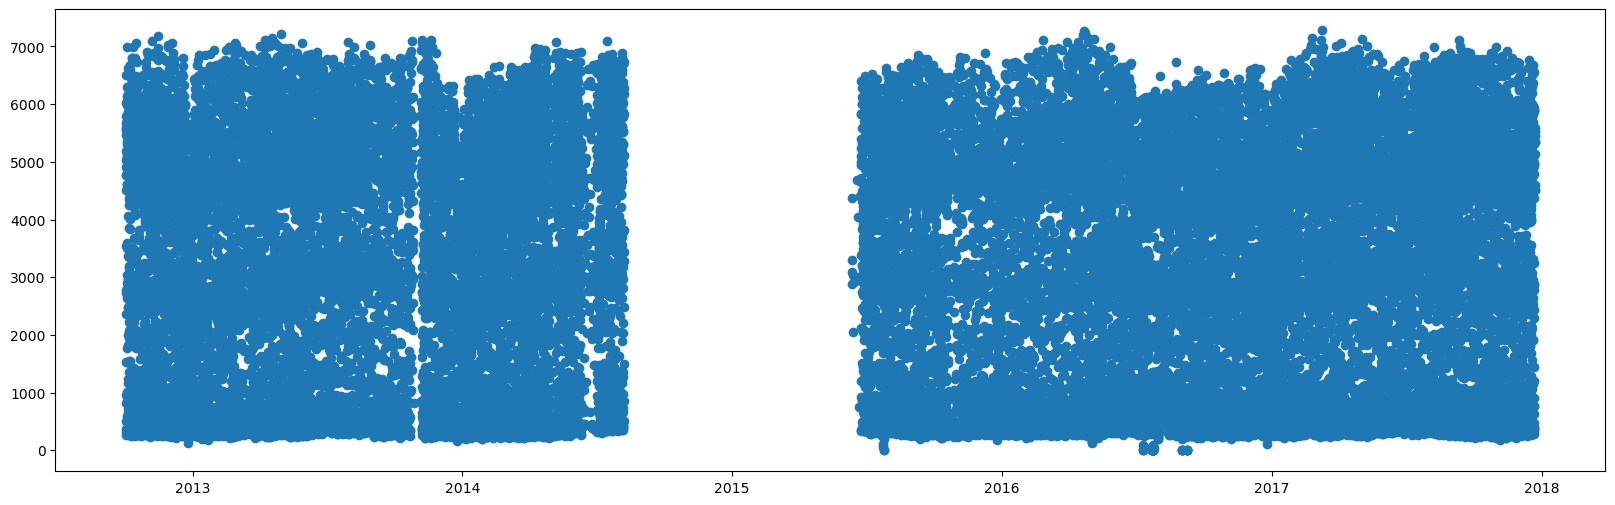

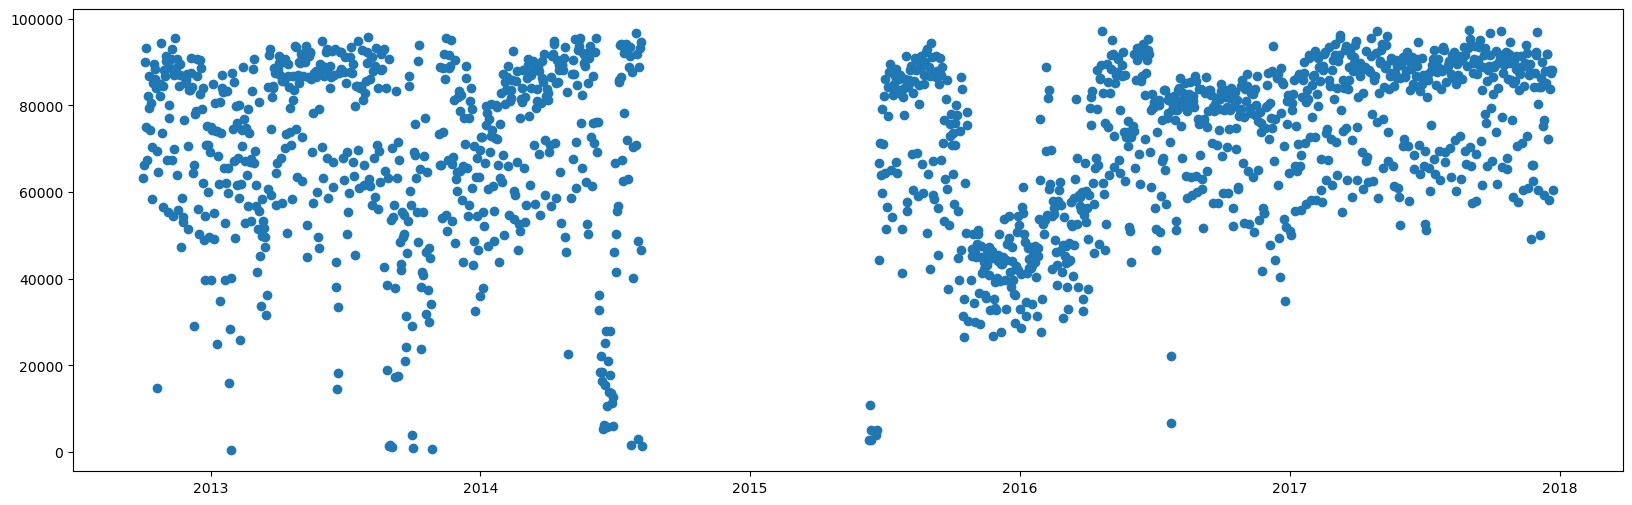

In [12]:
value_by_date=dataset.groupby("Date")["TrafficVolume"].sum()
plt.figure(figsize=(20,6))
plt.plot(dataset.Time.values,dataset.TrafficVolume.values,marker="o",linestyle="")
plt.figure(figsize=(20,6))
plt.plot(value_by_date.index,value_by_date.values,marker="o",linestyle="")

**Data shown on the scale of a day(total value of the day) by every year:**\
*Note that **whether the data is stationary** in each year should be checked*

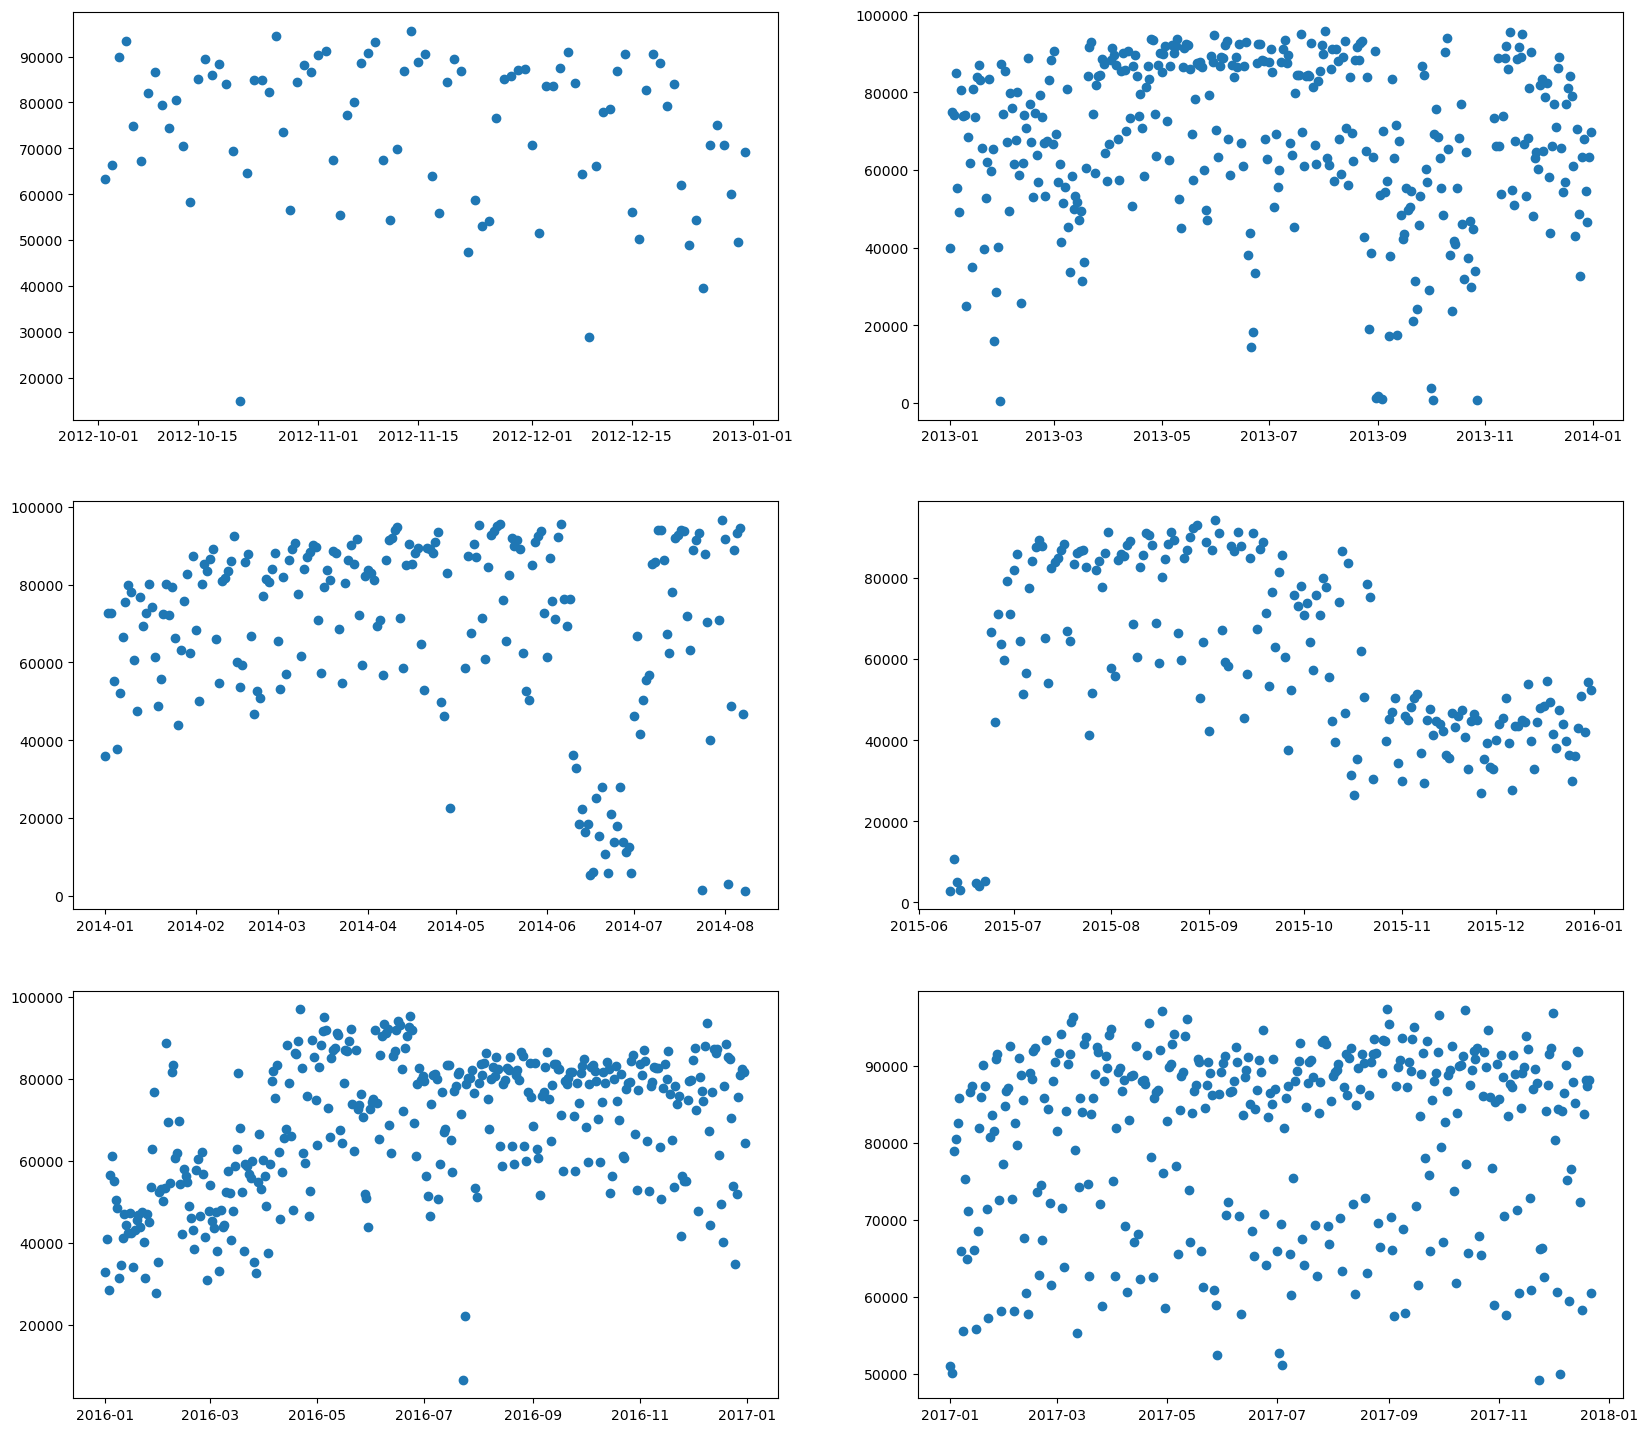

In [13]:
plt.figure(figsize=(20,18))
locs=[321,322,323,324,325,326]
years=[2012,2013,2014,2015,2016,2017]
for i in range(len(locs)):
    plt.subplot(locs[i])
    df=dataset[dataset["Year"]==years[i]]
    value_by_date_year=df.groupby("Date")["TrafficVolume"].sum()
    plt.plot(value_by_date_year.index,value_by_date_year.values,marker="o",linestyle="")
#     plt.plot(df.Time.values,df.TrafficVolume.values,marker="o",linestyle="")

**It can be concluded by the figures above that data between 2014-9 and 2015-6 is missing.**

**The time series data should also be seen from the perspective of the specific weekday/hour, which may affect the fluctuation of traffic volume in a week/day.**

<Axes: xlabel='DayOfWeek', ylabel='TrafficVolume'>

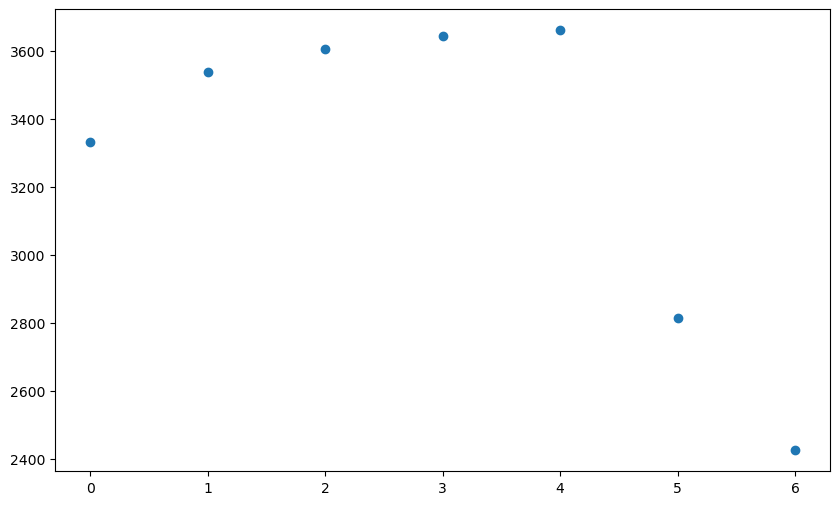

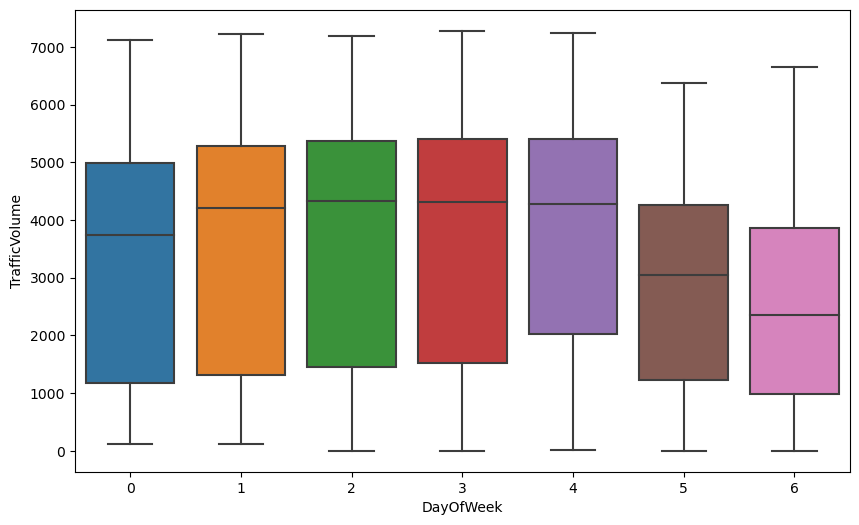

In [14]:
by_weekday=dataset.groupby("DayOfWeek")["TrafficVolume"].mean()
plt.figure(figsize=(10,6))
plt.plot(by_weekday.index,by_weekday.values,marker="o",linestyle="")
order=dataset.groupby("DayOfWeek")["TrafficVolume"].median().index
plt.figure(figsize=(10,6))
sns.boxplot(x="DayOfWeek",y="TrafficVolume",data=dataset,order=order)

<Axes: xlabel='Hour', ylabel='TrafficVolume'>

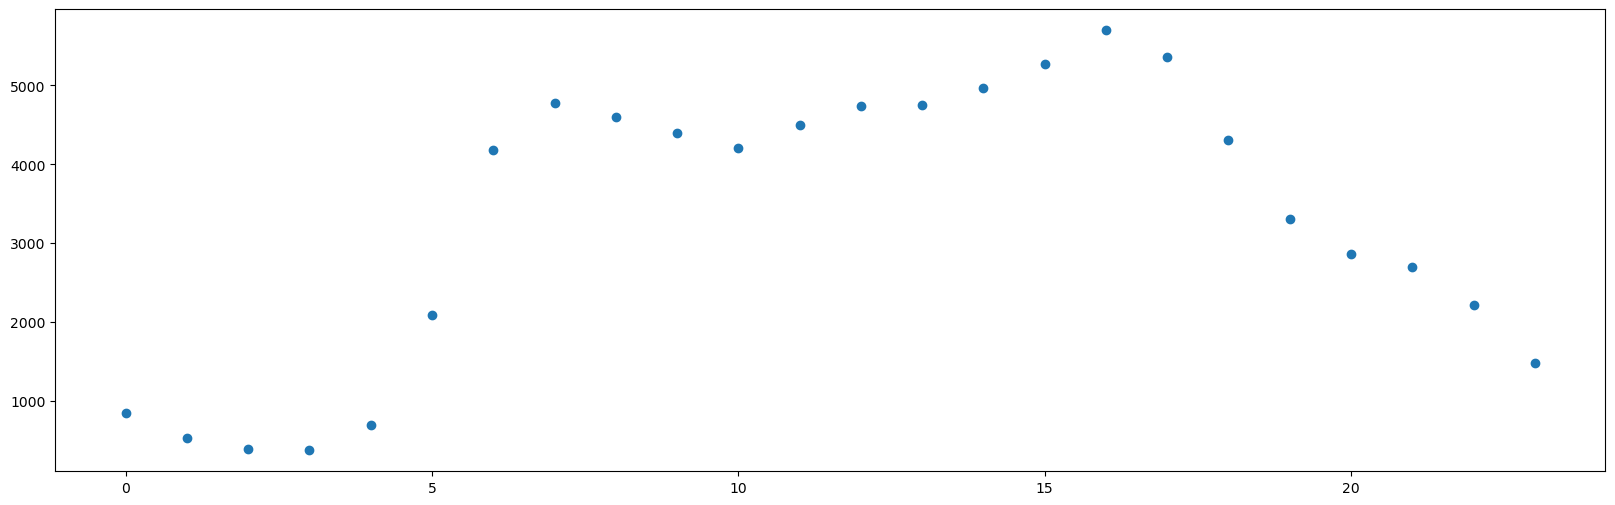

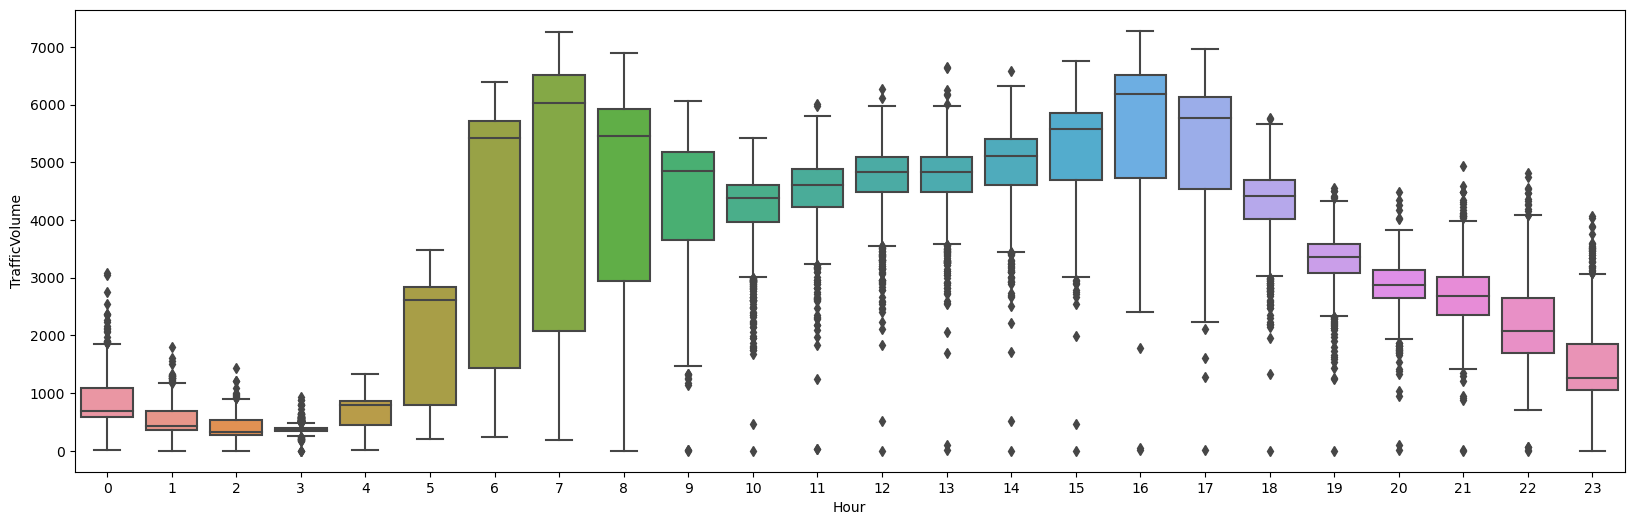

In [15]:
by_hour=dataset.groupby("Hour")["TrafficVolume"].mean()
plt.figure(figsize=(20,6))
plt.plot(by_hour.index,by_hour.values,marker="o",linestyle="")
order=dataset.groupby("Hour")["TrafficVolume"].median().index
plt.figure(figsize=(20,6))
sns.boxplot(x="Hour",y="TrafficVolume",data=dataset,order=order)

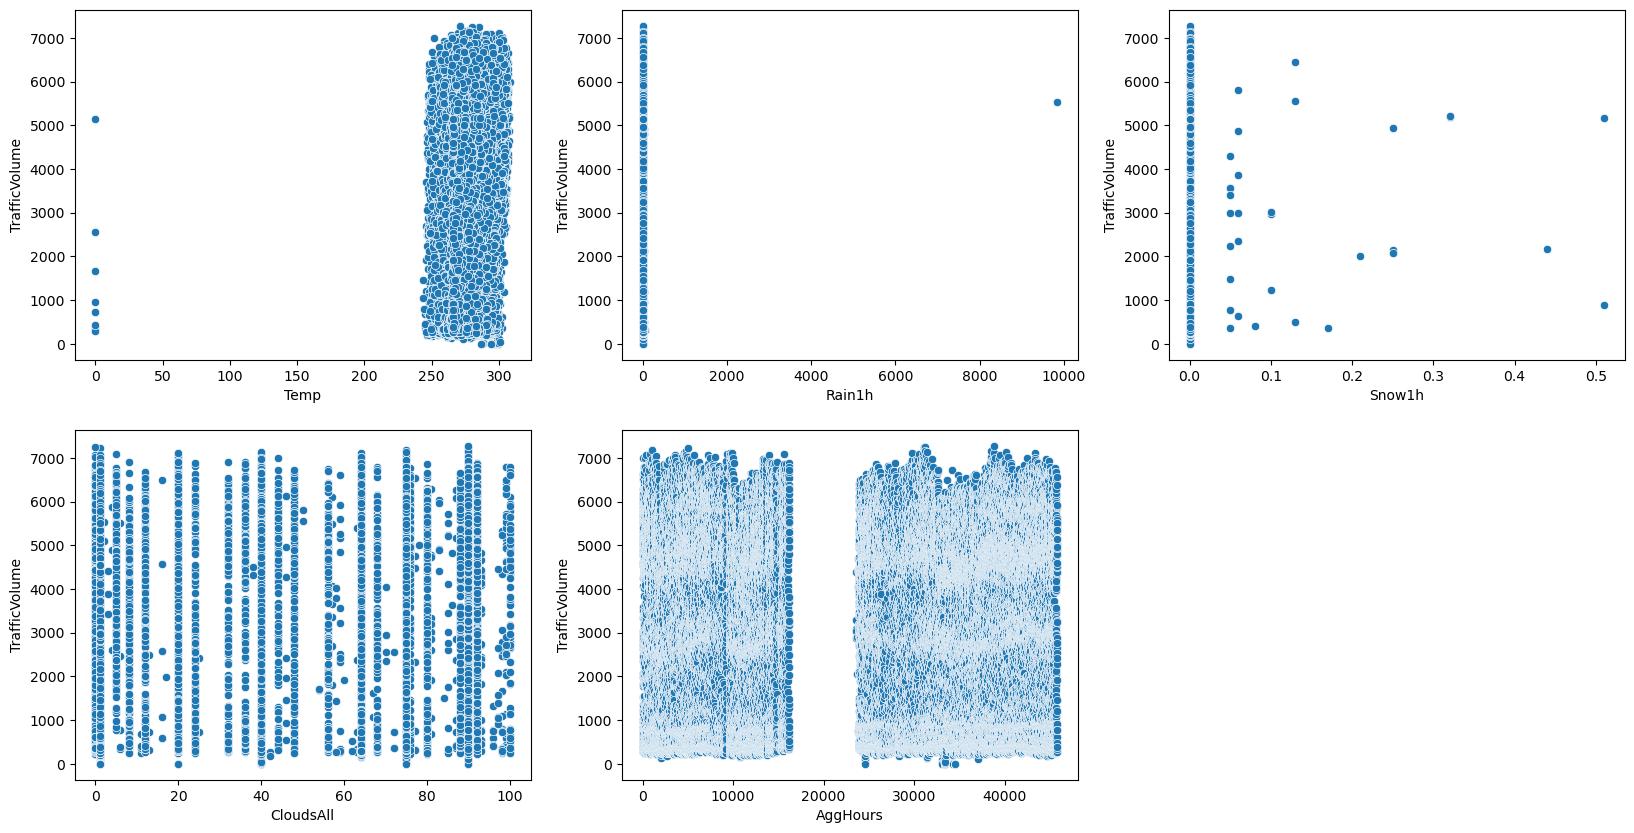

In [16]:
plt.figure(figsize=(20,10))
axes=plt.subplot()
locs=[231,232,233,234,235]
axs=["Temp","Rain1h","Snow1h","CloudsAll","AggHours"]
for i in range(len(locs)):
    plt.subplot(locs[i])
    sns.scatterplot(x=axs[i],y="TrafficVolume",data=dataset)

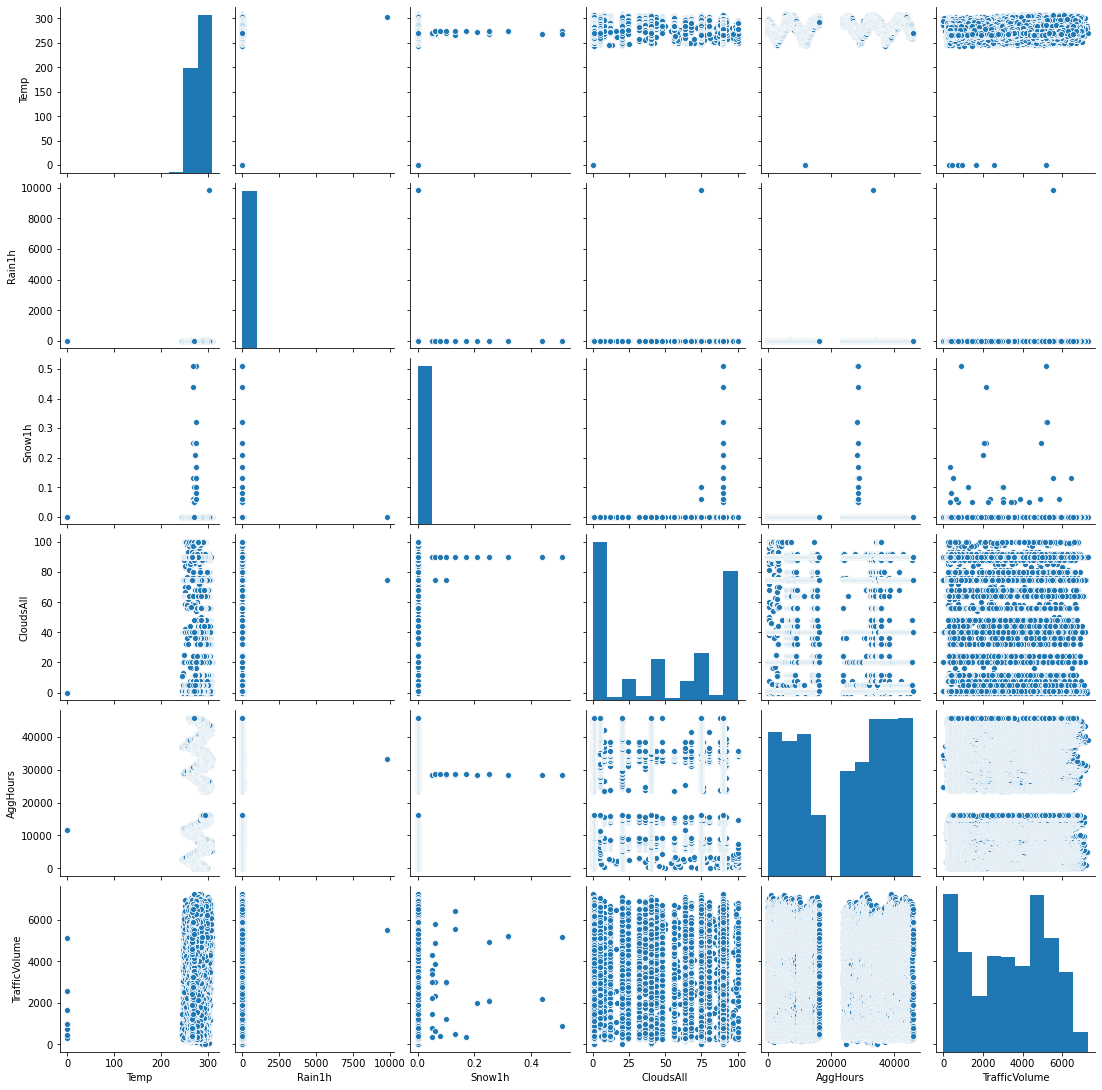

In [16]:
sns.pairplot(dataset[['Temp','Rain1h','Snow1h','CloudsAll',"AggHours","TrafficVolume"]])

In [17]:
len(dataset["WeatherDescription"].value_counts())
# len(set(dataset["WeatherDescription"]))

35

<Axes: xlabel='IsHoliday', ylabel='TrafficVolume'>

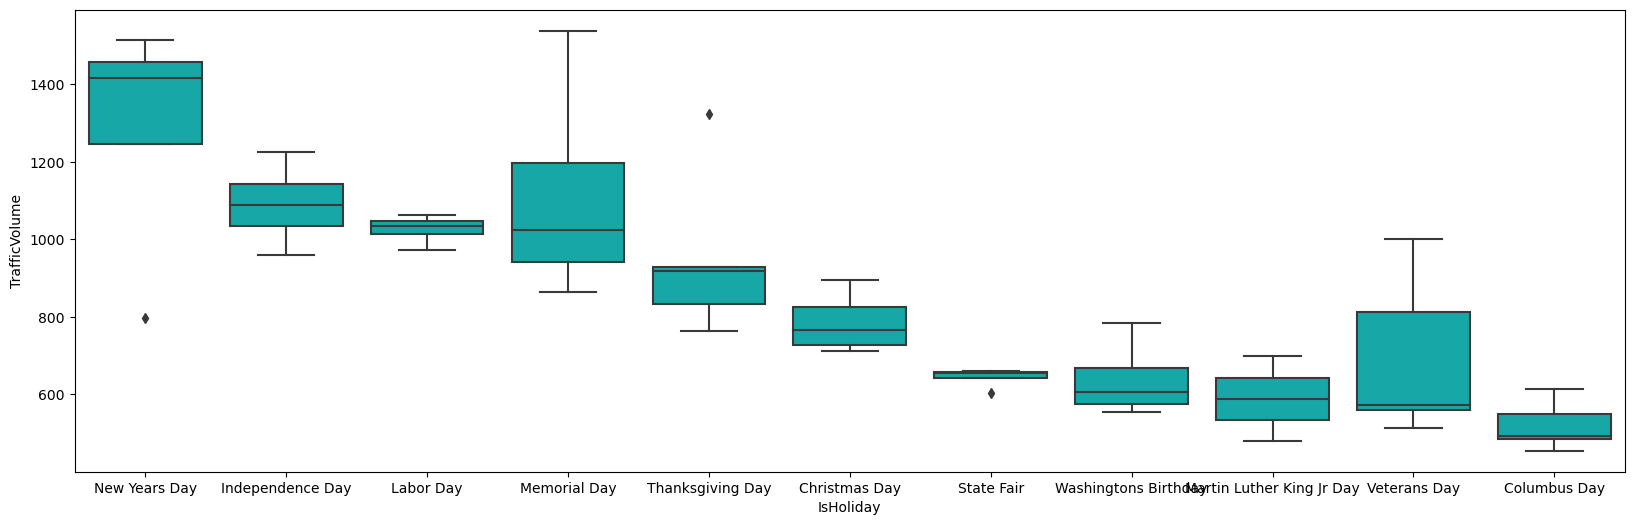

In [18]:
order=dataset.groupby("IsHoliday")["TrafficVolume"].median().sort_values(ascending=False).index
fig = plt.figure(figsize=(20,6))
sns.boxplot(x="IsHoliday",y="TrafficVolume",data=dataset,order=order,color="c")


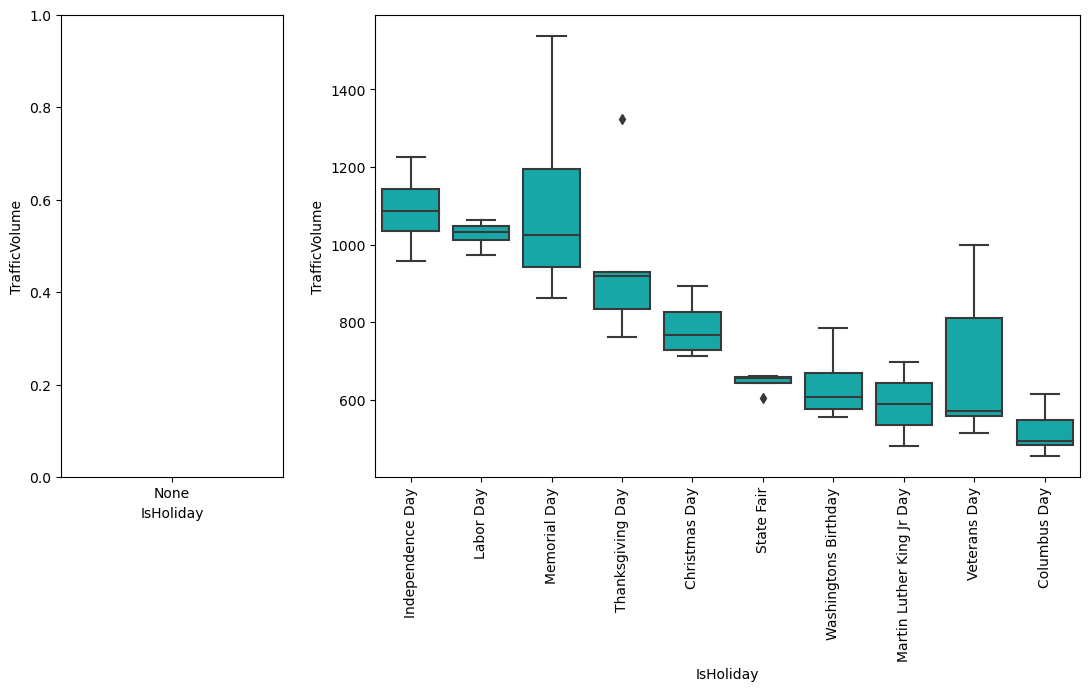

In [19]:
order=dataset.groupby("IsHoliday")["TrafficVolume"].median().sort_values(ascending=False)[1:].index
fig = plt.figure(figsize=(20,6))
plt.subplot(163)
ax1=sns.boxplot(x="IsHoliday",y="TrafficVolume",data=dataset,order=["None"],color="c")
plt.subplot(122)
ax2=sns.boxplot(x="IsHoliday",y="TrafficVolume",data=dataset,order=order,color="c")
ax2.set_xticklabels(labels=order,rotation=90)
plt.show()

<Axes: xlabel='WeatherMain', ylabel='TrafficVolume'>

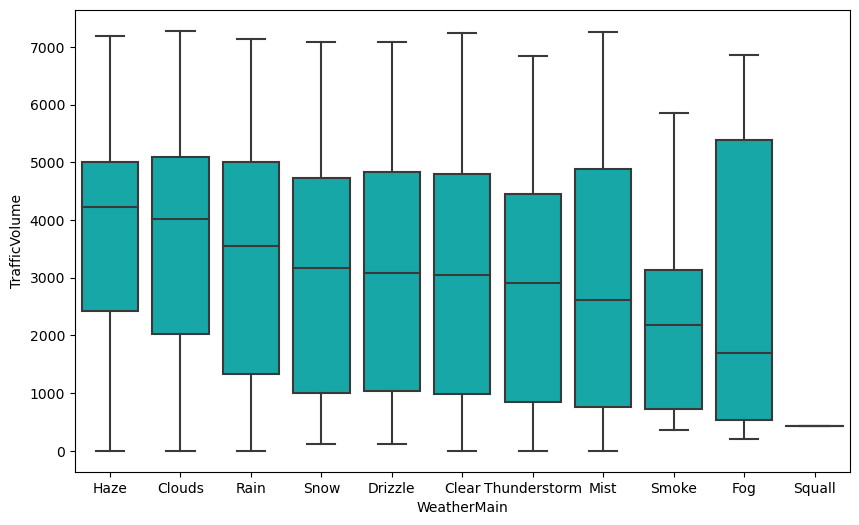

In [20]:
order=dataset.groupby("WeatherMain")["TrafficVolume"].median().sort_values(ascending=False).index
fig = plt.figure(figsize=(10,6))
sns.boxplot(x="WeatherMain",y="TrafficVolume",data=dataset,order=order,color="c")

In [21]:
w1=["Haze","Clouds"]
w2=["Rain","Snow","Drizzle","Clear","Thunderstorm","Mist"]
w3=["Smoke"]
w4=["Fog"]
w5=["Squall"]
dataset["WeatherMain_clps"]=dataset["WeatherMain"].map( lambda x:1 if x in w1 else 2 if x in w2 else 3 if x in w3 else 4 if x in w4 else 5)

In [22]:
dataset

,IsHoliday,Temp,Rain1h,Snow1h,CloudsAll,WeatherMain,WeatherDescription,Time,TrafficVolume,d_IsHoliday,AggHours,Year,Month,Date,Hour,DayOfWeek,HourDay,WeatherMain_clps
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,1,0.0,2012,10,2012-10-02,9,1,91,1
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,1,1.0,2012,10,2012-10-02,10,1,101,1
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,1,2.0,2012,10,2012-10-02,11,1,111,1
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,1,3.0,2012,10,2012-10-02,12,1,121,1
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,1,4.0,2012,10,2012-10-02,13,1,131,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,NaN,266.57,0.0,0.0,40,Clouds,scattered clouds,2017-12-22 12:00:00,5447,1,45771.0,2017,12,2017-12-22,12,4,124,1
39996,NaN,267.48,0.0,0.0,1,Clear,sky is clear,2017-12-22 13:00:00,5349,1,45772.0,2017,12,2017-12-22,13,4,134,2
39997,NaN,268.36,0.0,0.0,1,Clear,sky is clear,2017-12-22 14:00:00,5581,1,45773.0,2017,12,2017-12-22,14,4,144,2
39998,NaN,269.36,0.0,0.0,1,Clear,sky is clear,2017-12-22 15:00:00,5510,1,45774.0,2017,12,2017-12-22,15,4,154,2


<Axes: xlabel='WeatherMain_clps', ylabel='TrafficVolume'>

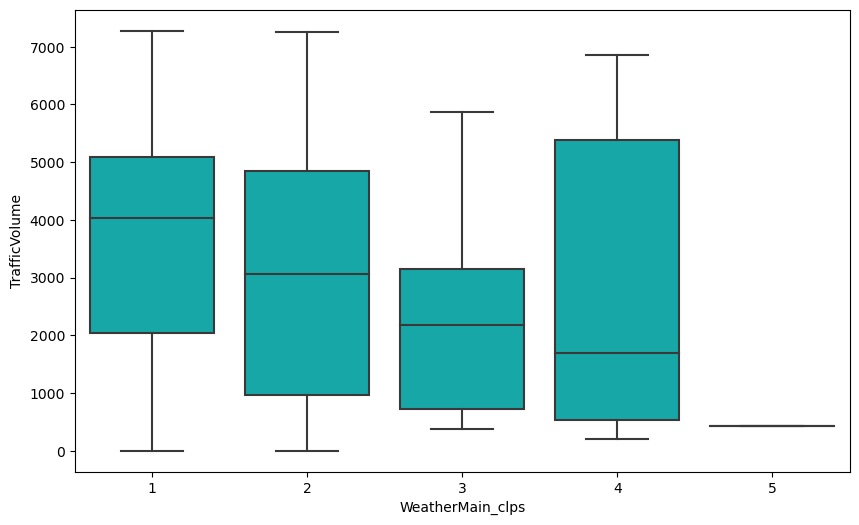

In [23]:
order=dataset.groupby("WeatherMain_clps")["TrafficVolume"].median().sort_values(ascending=False).index
fig = plt.figure(figsize=(10,6))
sns.boxplot(x="WeatherMain_clps",y="TrafficVolume",data=dataset,order=order,color="c")

<Axes: xlabel='Year', ylabel='TrafficVolume'>

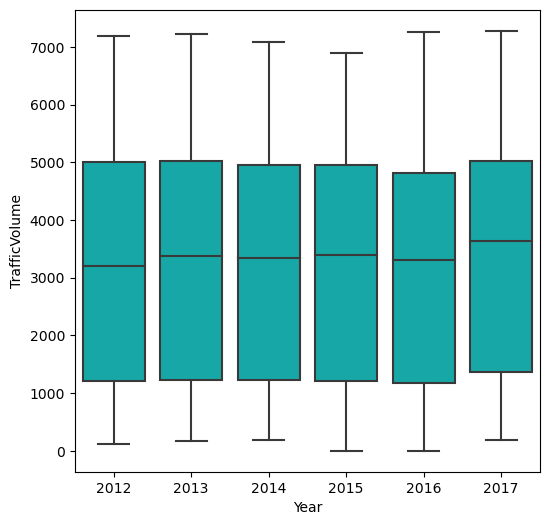

In [24]:
order=dataset.groupby("Year")["TrafficVolume"].median().index
fig = plt.figure(figsize=(6,6))
sns.boxplot(x="Year",y="TrafficVolume",data=dataset,order=order,color="c")

<Axes: xlabel='Month', ylabel='TrafficVolume'>

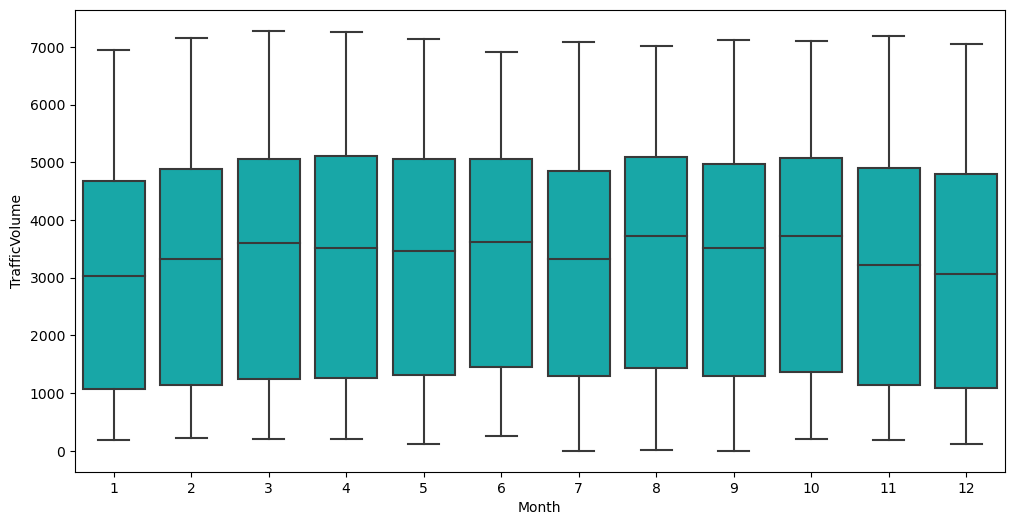

In [25]:
order=dataset.groupby("Month")["TrafficVolume"].median().index
fig = plt.figure(figsize=(12,6))
sns.boxplot(x="Month",y="TrafficVolume",data=dataset,order=order,color="c")

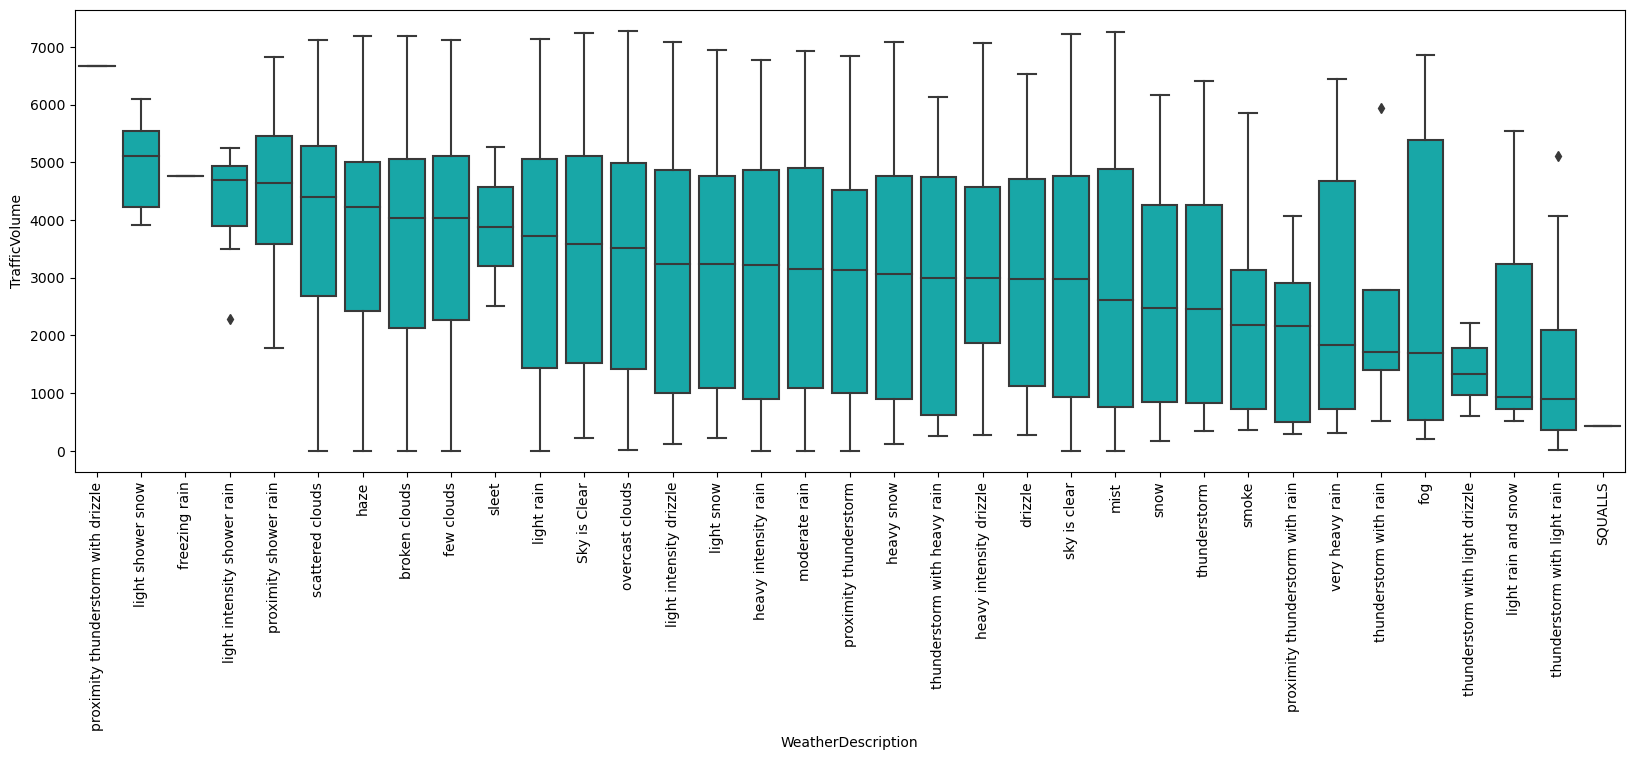

In [26]:
order=dataset.groupby("WeatherDescription")["TrafficVolume"].median().sort_values(ascending=False).index
fig = plt.figure(figsize=(20,6))
ax=sns.boxplot(x="WeatherDescription",y="TrafficVolume",data=dataset,order=order,color="c")
ax.set_xticklabels(labels=order,rotation=90)
plt.show()

# Regression 
**Regression on explanatory variables and time:**

In [27]:
# include the dummy variable
predictor_cands=["C(d_IsHoliday)","C(WeatherMain_clps)","C(HourDay)","Temp","Rain1h","Snow1h","AggHours","CloudsAll"]
y="TrafficVolume"
%run "util_formula.py"
fullmodel = modelFitting(y, predictor_cands, dataset)
# getAll(1,y,predictor_cands,dataset)
print(fullmodel.summary())

                            OLS Regression Results                            
Dep. Variable:          TrafficVolume   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     2878.
Date:                Wed, 22 Nov 2023   Prob (F-statistic):               0.00
Time:                        17:18:42   Log-Likelihood:            -2.5792e+05
No. Observations:               33820   AIC:                         5.162e+05
Df Residuals:                   33643   BIC:                         5.177e+05
Df Model:                         176                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

<Figure size 640x480 with 0 Axes>

## Multilinearity
**Validate the multilinearity using Variance Inflation Factor:**

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
predictors=["d_IsHoliday","WeatherMain_clps","HourDay","Temp","Rain1h","Snow1h","AggHours","CloudsAll"]
df_to_validate=dataset[predictors]
df_to_validate["constant"]=1
values_to_validate=df_to_validate[["d_IsHoliday","WeatherMain_clps","HourDay","Temp","Rain1h","Snow1h","AggHours","CloudsAll","constant"]].values
vif=[]
for i in range(9):
    a=variance_inflation_factor(values_to_validate,i)
    vif.insert(i,a)
vif_df=pd.DataFrame({"Predictor":predictors,"VIF":vif[:-1]})
vif_df

,Predictor,VIF
0,d_IsHoliday,0.000000
1,WeatherMain_clps,1.188182
2,HourDay,1.028286
3,Temp,1.071855
4,Rain1h,1.000202
5,Snow1h,1.001928
6,AggHours,1.052564
7,CloudsAll,1.186498


## Model Selection
### All Subset Searching
**Find the best model based on the Cp:**

In [32]:
# enumerate all models and obtain the results
models = pd.DataFrame({"model":[], "SSE": [], "R2":[], "AR2": [], "AIC": [], "BIC": [], "Pnum":[]})
for i in range(1,9):
    models = pd.concat([models,getAll(i, y, predictor_cands, dataset)],axis=0);
# get the Mallow's Cp Statistic
models = getMallowCp(models, fullmodel)

Processed  8 models on 1 predictors
Processed  28 models on 2 predictors
Processed  56 models on 3 predictors
Processed  70 models on 4 predictors
Processed  56 models on 5 predictors
Processed  28 models on 6 predictors
Processed  8 models on 7 predictors
Processed  1 models on 8 predictors


In [50]:
C=["Cp","AIC","BIC","SSE","R2"]
newdf = pd.DataFrame({"model":[], "SSE": [], "R2":[], "AR2": [], "AIC": [], "BIC": [], "Pnum":[],"Cp":[]})
# newdf=pd.concat([newdf,models.loc[models["Cp"]==models["Cp"].min()]],axis=0)
for c in C:
        newdf=pd.concat([newdf,models.loc[models[c]==models[c].min()]],axis=0)
        print(c)
        print(list(models.loc[models[c]==models[c].min()]["model"]))
# newdf.insert(0,"selection criterion",C)

Cp
[('C(WeatherMain_clps)', 'C(HourDay)', 'Temp', 'Snow1h', 'AggHours', 'CloudsAll')]
AIC
[('C(WeatherMain_clps)', 'C(HourDay)', 'Temp', 'Snow1h', 'AggHours', 'CloudsAll'), ('C(d_IsHoliday)', 'C(WeatherMain_clps)', 'C(HourDay)', 'Temp', 'Snow1h', 'AggHours', 'CloudsAll')]
BIC
[('C(HourDay)', 'Temp', 'CloudsAll'), ('C(d_IsHoliday)', 'C(HourDay)', 'Temp', 'CloudsAll')]
SSE
[('C(WeatherMain_clps)', 'C(HourDay)', 'Temp', 'Rain1h', 'Snow1h', 'AggHours', 'CloudsAll'), ('C(d_IsHoliday)', 'C(WeatherMain_clps)', 'C(HourDay)', 'Temp', 'Rain1h', 'Snow1h', 'AggHours', 'CloudsAll')]
R2
[('C(WeatherMain_clps)', 'C(HourDay)', 'Temp', 'Rain1h', 'Snow1h', 'AggHours', 'CloudsAll'), ('C(d_IsHoliday)', 'C(WeatherMain_clps)', 'C(HourDay)', 'Temp', 'Rain1h', 'Snow1h', 'AggHours', 'CloudsAll')]


In [46]:
newdf

,model,SSE,R2,AR2,AIC,BIC,Pnum,Cp
24,"(C(WeatherMain_clps), C(HourDay), Temp, Snow1h...",8.332027e+09,-0.93771,-0.937386,516189.590298,517673.060439,6.0,-162.794708
24,"(C(WeatherMain_clps), C(HourDay), Temp, Snow1h...",8.332027e+09,-0.93771,-0.937386,516189.590298,517673.060439,6.0,-162.794708
3,"(C(d_IsHoliday), C(WeatherMain_clps), C(HourDa...",8.332027e+09,-0.93771,-0.937386,516189.590298,517673.060439,7.0,-160.794708
39,"(C(HourDay), Temp, CloudsAll)",8.344009e+09,-0.93762,-0.937307,516226.189040,517659.086336,3.0,-120.415264
18,"(C(d_IsHoliday), C(HourDay), Temp, CloudsAll)",8.344009e+09,-0.93762,-0.937307,516226.189040,517659.086336,4.0,-118.415264
7,"(C(WeatherMain_clps), C(HourDay), Temp, Rain1h...",8.331976e+09,-0.93771,-0.937384,516191.383926,517683.282875,7.0,-161.000000
0,"(C(d_IsHoliday), C(WeatherMain_clps), C(HourDa...",8.331976e+09,-0.93771,-0.937384,516191.383926,517683.282875,8.0,-159.000000
7,"(C(WeatherMain_clps), C(HourDay), Temp, Rain1h...",8.331976e+09,-0.93771,-0.937384,516191.383926,517683.282875,7.0,-161.000000
0,"(C(d_IsHoliday), C(WeatherMain_clps), C(HourDa...",8.331976e+09,-0.93771,-0.937384,516191.383926,517683.282875,8.0,-159.000000


### Forward Selection
**Use forward selection to get the best model:**

In [51]:
fwmodel = forward(y, predictor_cands, dataset, 'AIC')
fwmodel.summary()

['C(HourDay)']
['C(HourDay)', 'Temp']
['C(HourDay)', 'Temp', 'CloudsAll']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)', 'Snow1h']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)', 'Snow1h', 'AggHours']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          TrafficVolume   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     2894.
Date:                Wed, 22 Nov 2023   Prob (F-statistic):               0.00
Time:                        17:37:49   Log-Likelihood:            -2.5792e+05
No. Observations:               33820   AIC:                         5.162e+05
Df Residuals:                   33644   BIC:                         5.177e+05
Df Model:                         175                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                 -847.5860     67.859    -12.490      0.000    -980.592    -714.580
C(HourDay)[T.1]            -17.7992     48.920     -0.364      0.716    -113.684      78.086
C(HourDay)[T.2]              2.4929     48.800      0.051      0.959     -93.157      98.143
C(HourDay)[T.3]             43.2015     49.103      0.880      0.379     -53.042     139.445
C(HourDay)[T.4]            148.7136     48.567      3.062      0.002      53.521     243.906
C(HourDay)[T.5]            635.1367     48.859     12.999      0.000     539.372     730.901
C(HourDay)[T.6]            775.0182     49.165     15.764      0.000     678.654     871.383
C(HourDay)[T.10]          -239.5544     49.228     -4.866      0.000    -336.043    -143.066
C(HourDay)[T.11]          -243.2594     49.228     -4.941      0.000    -339.748    -146.771
C(HourDay)[T.12]          -222.8234     49.292     -4.520      0.000    -319.437    -126.210
C(HourDay)[T.13]          -218.8107     48.802     -4.484      0.000    -314.464    -123.157
C(HourDay)[T.14]          -159.3638     48.743     -3.270      0.001    -254.901     -63.827
C(HourDay)[T.15]           160.3237     48.630      3.297      0.001      65.008     255.639
C(HourDay)[T.16]           248.1639     48.982      5.066      0.000     152.158     344.170
C(HourDay)[T.20]          -329.7391     48.859     -6.749      0.000    -425.505    -233.973
C(HourDay)[T.21]          -335.4172     49.230     -6.813      0.000    -431.910    -238.925
C(HourDay)[T.22]          -308.1019     48.862     -6.306      0.000    -403.872    -212.331
C(HourDay)[T.23]          -312.9332     48.983     -6.389      0.000    -408.942    -216.925
C(HourDay)[T.24]          -271.8854     48.861     -5.564      0.000    -367.655    -176.116
C(HourDay)[T.25]           -15.7587     48.988     -0.322      0.748    -111.777      80.259
C(HourDay)[T.26]            29.1004     49.356      0.590      0.555     -67.639     125.840
C(HourDay)[T.30]          -280.2864     49.227     -5.694      0.000    -376.773    -183.800
C(HourDay)[T.31]          -263.9300     49.355     -5.348      0.000    -360.668    -167.192
C(HourDay)[T.32]          -242.8148     49.685     -4.887      0.000    -340.200    -145.430
C(HourDay)[T.33]          -249.3906     49.292     -5.059      0.000    -346.004    -152.777
C(HourDay)[T.34]          -218.7625     48.689     -4.493      0.000    -314.195    -123.330
C(HourDay)[T.35]          -206.6740     49.365     -4.187      0.000    -303.431    -109.917
C(HourDay)[T.36]          -220.7027     49.686     -4.442      0.000    -318.088    -123.317
C(HourDay)[T.40]           183.0784     49.105      3.728      0.000      86.831     279.326
C(HourDay)[T.41]           224.1750     49.045      4.571      0.000     128.046     320.304
C(HourDay)[T.4

### Backward Selection
**Use backward selection to get the best model:**

In [34]:
bwmodel = backward(y, predictor_cands, dataset, 'AIC')
bwmodel.summary()

['Rain1h']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          TrafficVolume   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     2878.
Date:                Mon, 20 Nov 2023   Prob (F-statistic):               0.00
Time:                        15:55:18   Log-Likelihood:            -2.5791e+05
No. Observations:               33820   AIC:                         5.162e+05
Df Residuals:                   33643   BIC:                         5.177e+05
Df Model:                         176                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                 -874.0282     68.446    -12.770      0.000   -1008.185    -739.871
C(d_IsHoliday)[T.1]        226.7195     77.202      2.937      0.003      75.400     378.039
C(WeatherMain_clps)[T.2]   -37.4669      6.117     -6.125      0.000     -49.457     -25.477
C(WeatherMain_clps)[T.3]    52.4634    138.415      0.379      0.705    -218.834     323.761
C(WeatherMain_clps)[T.4]     4.5507     38.638      0.118      0.906     -71.181      80.283
C(WeatherMain_clps)[T.5]  -244.3753    498.877     -0.490      0.624   -1222.191     733.441
C(HourDay)[T.1]              4.9164     49.522      0.099      0.921     -92.149     101.982
C(HourDay)[T.2]             25.2431     49.406      0.511      0.609     -71.594     122.080
C(HourDay)[T.3]             58.0105     49.356      1.175      0.240     -38.728     154.749
C(HourDay)[T.4]            169.3769     49.068      3.452      0.001      73.201     265.552
C(HourDay)[T.5]            661.1708     49.651     13.316      0.000     563.853     758.488
C(HourDay)[T.6]            801.0490     49.952     16.036      0.000     703.141     898.956
C(HourDay)[T.10]          -213.5209     50.014     -4.269      0.000    -311.551    -115.491
C(HourDay)[T.11]          -217.2255     50.015     -4.343      0.000    -315.256    -119.195
C(HourDay)[T.12]          -196.7873     50.077     -3.930      0.000    -294.941     -98.634
C(HourDay)[T.13]          -192.7764     49.595     -3.887      0.000    -289.985     -95.568
C(HourDay)[T.14]          -133.3246     49.537     -2.691      0.007    -230.419     -36.230
C(HourDay)[T.15]           186.3578     49.426      3.770      0.000      89.482     283.234
C(HourDay)[T.16]           274.1980     49.772      5.509      0.000     176.643     371.753
C(HourDay)[T.20]          -303.7043     49.652     -6.117      0.000    -401.023    -206.386
C(HourDay)[T.21]          -309.3848     50.016     -6.186      0.000    -407.419    -211.351
C(HourDay)[T.22]          -282.0651     49.654     -5.681      0.000    -379.389    -184.742
C(HourDay)[T.23]          -286.8984     49.773     -5.764      0.000    -384.456    -189.341
C(HourDay)[T.24]          -245.8512     49.653     -4.951      0.000    -343.174    -148.529
C(HourDay)[T.25]            10.2705     49.778      0.206      0.837     -87.296     107.837
C(HourDay)[T.26]            55.1355     50.140      1.100      0.272     -43.141     153.412
C(HourDay)[T.30]          -254.2498     50.014     -5.084      0.000    -352.278    -156.222
C(HourDay)[T.31]          -237.8963     50.139     -4.745      0.000    -336.171    -139.621
C(HourDay)[T.32]          -216.7848     50.464     -4.296      0.000    -315.696    -117.873
C(HourDay)[T.33]          -223.3532     50.077     -4.460      0.000    -321.507    -125.200
C(HourDay)[T.3

## Interaction considered
**generated from the selected model:**

In [35]:
model_selected=models.loc[models["Cp"]==models["Cp"].min()]# also fwmodel
candidate=list(model_selected["model"].values[0])
cand_2Inter = []
for p1 in candidate:
    for p2 in candidate:
        if p1 == p2:
            cand_2Inter.append(p1);
        else:
            cand_2Inter.append(p1+':'+p2);
                
print(cand_2Inter)
print(len(cand_2Inter))

['C(d_IsHoliday)', 'C(d_IsHoliday):C(WeatherMain_clps)', 'C(d_IsHoliday):C(HourDay)', 'C(d_IsHoliday):Temp', 'C(d_IsHoliday):Snow1h', 'C(d_IsHoliday):AggHours', 'C(d_IsHoliday):CloudsAll', 'C(WeatherMain_clps):C(d_IsHoliday)', 'C(WeatherMain_clps)', 'C(WeatherMain_clps):C(HourDay)', 'C(WeatherMain_clps):Temp', 'C(WeatherMain_clps):Snow1h', 'C(WeatherMain_clps):AggHours', 'C(WeatherMain_clps):CloudsAll', 'C(HourDay):C(d_IsHoliday)', 'C(HourDay):C(WeatherMain_clps)', 'C(HourDay)', 'C(HourDay):Temp', 'C(HourDay):Snow1h', 'C(HourDay):AggHours', 'C(HourDay):CloudsAll', 'Temp:C(d_IsHoliday)', 'Temp:C(WeatherMain_clps)', 'Temp:C(HourDay)', 'Temp', 'Temp:Snow1h', 'Temp:AggHours', 'Temp:CloudsAll', 'Snow1h:C(d_IsHoliday)', 'Snow1h:C(WeatherMain_clps)', 'Snow1h:C(HourDay)', 'Snow1h:Temp', 'Snow1h', 'Snow1h:AggHours', 'Snow1h:CloudsAll', 'AggHours:C(d_IsHoliday)', 'AggHours:C(WeatherMain_clps)', 'AggHours:C(HourDay)', 'AggHours:Temp', 'AggHours:Snow1h', 'AggHours', 'AggHours:CloudsAll', 'CloudsAl

In [36]:
# forward selection with interaction considered
fwmodel_inter = forward(y, cand_2Inter, dataset, 'AIC')
print(fwmodel_inter.summary())

['C(HourDay):Temp']
['C(HourDay):Temp', 'C(d_IsHoliday):C(HourDay)']
['C(HourDay):Temp', 'C(d_IsHoliday):C(HourDay)', 'C(WeatherMain_clps):CloudsAll']
['C(HourDay):Temp', 'C(d_IsHoliday):C(HourDay)', 'C(WeatherMain_clps):CloudsAll', 'C(HourDay):Snow1h']
['C(HourDay):Temp', 'C(d_IsHoliday):C(HourDay)', 'C(WeatherMain_clps):CloudsAll', 'C(HourDay):Snow1h', 'Temp:CloudsAll']
['C(HourDay):Temp', 'C(d_IsHoliday):C(HourDay)', 'C(WeatherMain_clps):CloudsAll', 'C(HourDay):Snow1h', 'Temp:CloudsAll', 'C(WeatherMain_clps):Temp']
['C(HourDay):Temp', 'C(d_IsHoliday):C(HourDay)', 'C(WeatherMain_clps):CloudsAll', 'C(HourDay):Snow1h', 'Temp:CloudsAll', 'C(WeatherMain_clps):Temp', 'C(WeatherMain_clps)']
['C(HourDay):Temp', 'C(d_IsHoliday):C(HourDay)', 'C(WeatherMain_clps):CloudsAll', 'C(HourDay):Snow1h', 'Temp:CloudsAll', 'C(WeatherMain_clps):Temp', 'C(WeatherMain_clps)', 'C(WeatherMain_clps):AggHours']
['C(HourDay):Temp', 'C(d_IsHoliday):C(HourDay)', 'C(WeatherMain_clps):CloudsAll', 'C(HourDay):Snow1h

## Model diagnostics using residuals
**no interaction**

In [52]:
model_to_diag=fwmodel

### Normal Distribution


<Figure size 600x600 with 0 Axes>

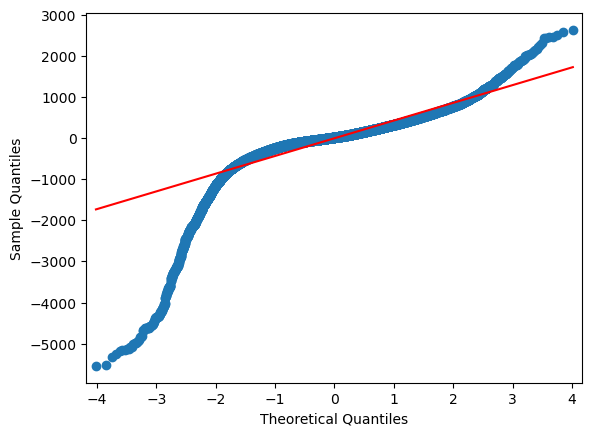

In [53]:
import scipy.stats as stats
# check the normality of the data
fig = plt.figure(figsize=(6,6))
fig = sm.qqplot(model_to_diag.resid, stats.distributions.norm, line='r') 

**Shapiro-Wilk Test with interaction considered:**

In [54]:
# Example of the Shapiro-Wilk Normality Test
from scipy.stats import shapiro
resid_data = list(model_to_diag.resid.values)
stat, p = shapiro(resid_data)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Probably Gaussian')
else:
    print('Probably not Gaussian')

stat=0.755, p=0.000
Probably not Gaussian


### Non-constant Variance
**interaction is considered:**

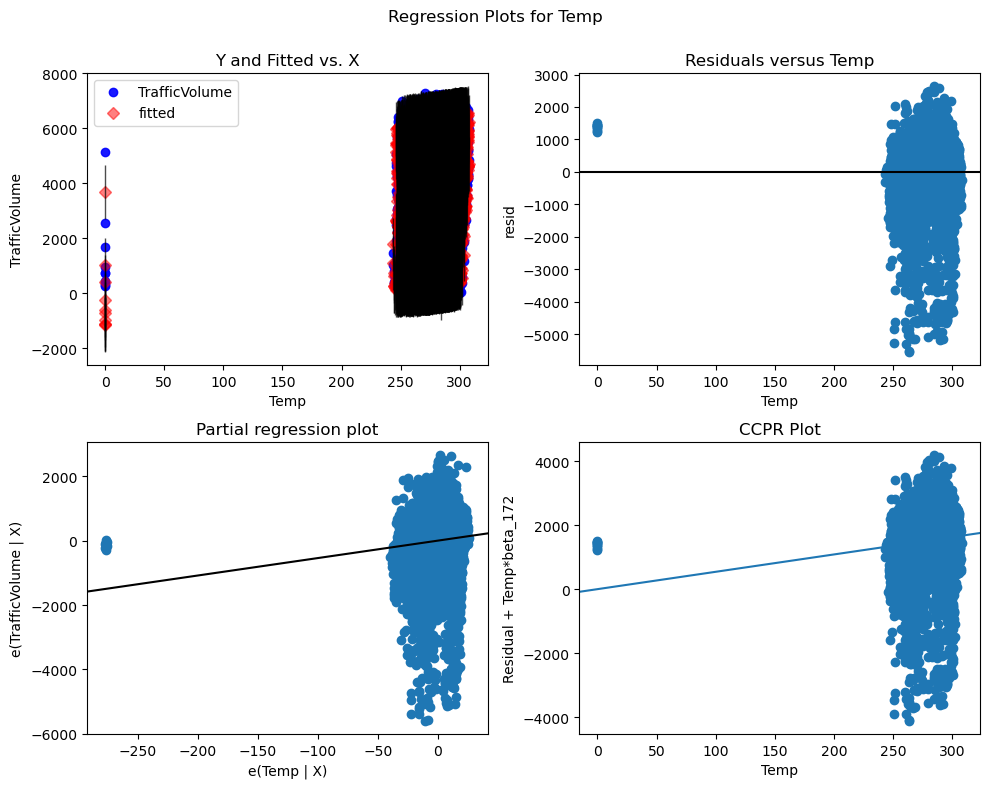

In [56]:
# fitted results versus a single predictor
fig = plt.figure(figsize=(10,8))
fig = sm.graphics.plot_regress_exog(model_to_diag, "Temp", fig=fig)

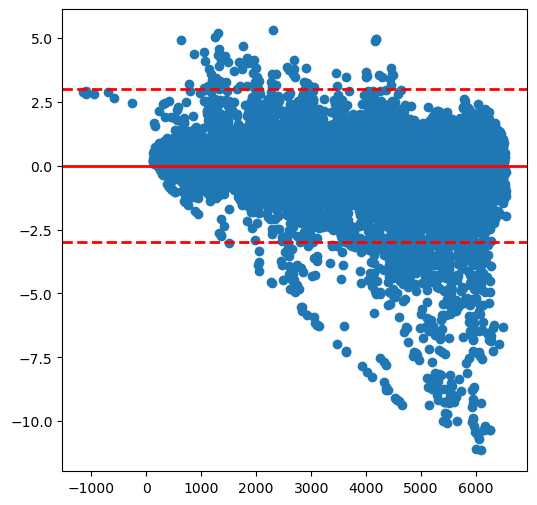

In [57]:
# check the residuals against fitted values
fig = plt.figure(figsize=(6,6))
plt.scatter(model_to_diag.fittedvalues, model_to_diag.resid_pearson)
plt.axhline(y=0, linewidth=2, color = 'r')
plt.axhline(y=3, linestyle='dashed', linewidth=2, color = 'r')
plt.axhline(y=-3, linestyle='dashed', linewidth=2, color = 'r')

In [58]:
from scipy.stats import levene
resid_array=model_to_diag.resid.sort_values()
resid_data=list(resid_array.values)
nslice=int(len(resid_array)/2)
levene(resid_data[:nslice],resid_data[nslice+1:])


LeveneResult(statistic=251.61936734973844, pvalue=1.8419730573346098e-56)

In [59]:
from scipy.stats import spearmanr
x=predictors
abse=np.abs(model_to_diag.resid)
for i in x:
    print(spearmanr(dataset[i], abse))

SignificanceResult(statistic=nan, pvalue=nan)
SignificanceResult(statistic=-0.043353122618334856, pvalue=1.5092255444140322e-15)
SignificanceResult(statistic=0.29534573973775047, pvalue=0.0)
SignificanceResult(statistic=0.027809496106284925, pvalue=3.136973877713028e-07)
SignificanceResult(statistic=-0.007188049922607708, pvalue=0.18621276391988106)
SignificanceResult(statistic=0.02021531128762888, pvalue=0.0002009003502219018)
SignificanceResult(statistic=-0.006237083348101421, pvalue=0.2513891493792658)
SignificanceResult(statistic=0.03136556201953755, pvalue=7.955407090097688e-09)


### Independence

(Text(0.5, 0, 'Index'), Text(0, 0.5, 'Residual'))

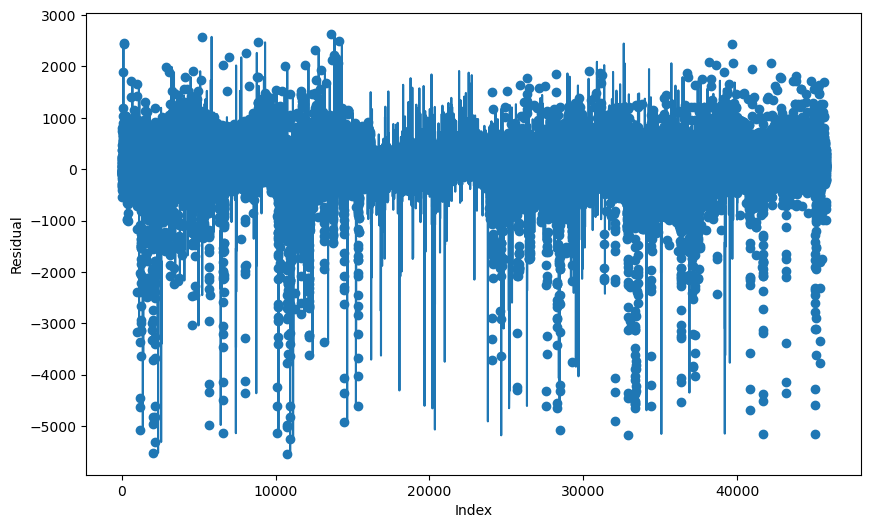

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(dataset['AggHours']-1, model_to_diag.resid)
plt.plot(model_to_diag.resid)
plt.xlabel('Index'), plt.ylabel('Residual')

In [61]:
from statsmodels.stats.stattools import durbin_watson
#perform Durbin-Watson test
durbin_watson(model_to_diag.resid)

0.3982729958759293

#### generate residual dataframe

In [62]:
resid_df=pd.DataFrame({"Time":dataset["Time"],"residual":model_to_diag.resid}).set_index("Time")
data = resid_df

#### draw acf and pacf

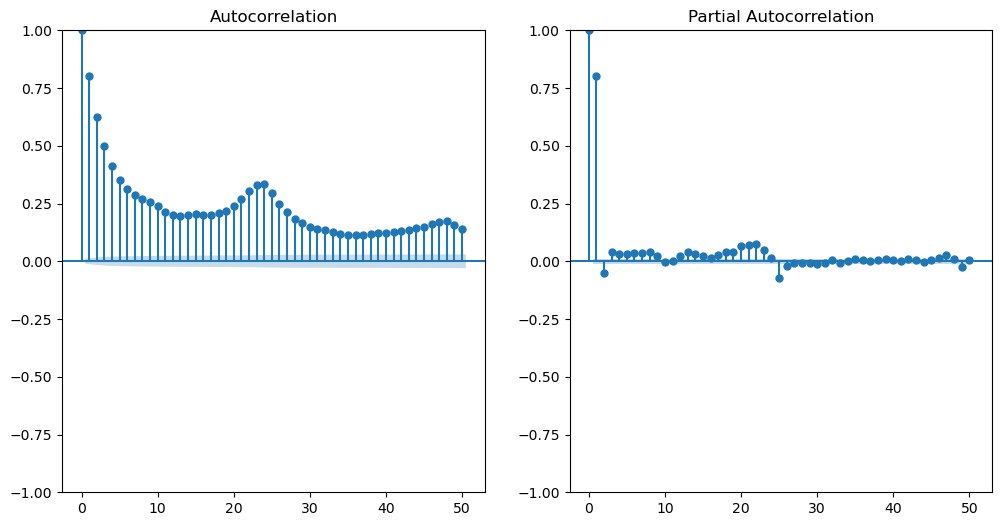

In [63]:
# graphical exploration
alpha=0.05
lags=50
fig, ax = plt.subplots(1,2,figsize=(12,6))
fig = sgt.plot_acf(data, ax=ax[0], lags=lags, alpha=alpha, unbiased=True)
fig = sgt.plot_pacf(data, ax=ax[1], lags=lags, alpha=alpha, method='ols')

## Model adjustment (transformation)
**not considering interaction:**

In [48]:
dataset_t=dataset.copy()
# dataset_t["TrafficVolume"]=np.log(dataset["TrafficVolume"])
# dataset_t["Rain1h"]=np.log(dataset["Rain1h"])
# dataset_t["Snow1h"]=np.log(dataset["Snow1h"])
# dataset_t["CloudsAll"]=np.log(dataset["CloudsAll"])
# eliminate the infinity terms produced by log functions
# dataset_t=dataset_t.replace(-np.inf,0)

In [49]:
# include the dummy variable
predictor_cands=["C(d_IsHoliday)","C(WeatherMain_clps)","C(HourDay)","Temp","Rain1h","Snow1h","AggHours","CloudsAll"]
y="TrafficVolume"
fullmodel_t = modelFitting(y, predictor_cands, dataset_t)
# print(fullmodel_t.summary())

fwmodel_t = forward(y, predictor_cands, dataset_t, 'AIC')
fwmodel_t.summary()

['C(HourDay)']
['C(HourDay)', 'Temp']
['C(HourDay)', 'Temp', 'CloudsAll']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)', 'C(d_IsHoliday)']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)', 'C(d_IsHoliday)', 'Snow1h']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)', 'C(d_IsHoliday)', 'Snow1h', 'AggHours']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          TrafficVolume   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     2878.
Date:                Sun, 19 Nov 2023   Prob (F-statistic):               0.00
Time:                        22:54:34   Log-Likelihood:            -2.5791e+05
No. Observations:               33820   AIC:                         5.162e+05
Df Residuals:                   33643   BIC:                         5.177e+05
Df Model:                         176                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                 -874.0282     68.446    -12.770      0.000   -1008.185    -739.871
C(HourDay)[T.1]              4.9164     49.522      0.099      0.921     -92.149     101.982
C(HourDay)[T.2]             25.2431     49.406      0.511      0.609     -71.594     122.080
C(HourDay)[T.3]             58.0105     49.356      1.175      0.240     -38.728     154.749
C(HourDay)[T.4]            169.3769     49.068      3.452      0.001      73.201     265.552
C(HourDay)[T.5]            661.1708     49.651     13.316      0.000     563.853     758.488
C(HourDay)[T.6]            801.0490     49.952     16.036      0.000     703.141     898.956
C(HourDay)[T.10]          -213.5209     50.014     -4.269      0.000    -311.551    -115.491
C(HourDay)[T.11]          -217.2255     50.015     -4.343      0.000    -315.256    -119.195
C(HourDay)[T.12]          -196.7873     50.077     -3.930      0.000    -294.941     -98.634
C(HourDay)[T.13]          -192.7764     49.595     -3.887      0.000    -289.985     -95.568
C(HourDay)[T.14]          -133.3246     49.537     -2.691      0.007    -230.419     -36.230
C(HourDay)[T.15]           186.3578     49.426      3.770      0.000      89.482     283.234
C(HourDay)[T.16]           274.1980     49.772      5.509      0.000     176.643     371.753
C(HourDay)[T.20]          -303.7043     49.652     -6.117      0.000    -401.023    -206.386
C(HourDay)[T.21]          -309.3848     50.016     -6.186      0.000    -407.419    -211.351
C(HourDay)[T.22]          -282.0651     49.654     -5.681      0.000    -379.389    -184.742
C(HourDay)[T.23]          -286.8984     49.773     -5.764      0.000    -384.456    -189.341
C(HourDay)[T.24]          -245.8512     49.653     -4.951      0.000    -343.174    -148.529
C(HourDay)[T.25]            10.2705     49.778      0.206      0.837     -87.296     107.837
C(HourDay)[T.26]            55.1355     50.140      1.100      0.272     -43.141     153.412
C(HourDay)[T.30]          -254.2498     50.014     -5.084      0.000    -352.278    -156.222
C(HourDay)[T.31]          -237.8963     50.139     -4.745      0.000    -336.171    -139.621
C(HourDay)[T.32]          -216.7848     50.464     -4.296      0.000    -315.696    -117.873
C(HourDay)[T.33]          -223.3532     50.077     -4.460      0.000    -321.507    -125.200
C(HourDay)[T.34]          -192.7292     49.484     -3.895      0.000    -289.720     -95.738
C(HourDay)[T.35]          -180.6462     50.149     -3.602      0.000    -278.939     -82.353
C(HourDay)[T.36]          -194.6701     50.465     -3.858      0.000    -293.582     -95.758
C(HourDay)[T.40]           209.1137     49.893      4.191      0.000     111.321     306.906
C(HourDay)[T.41]           250.2095     49.834      5.021      0.000     152.533     347.886
C(HourDay)[T.4

In [50]:
# enumerate all models and obtain the results
models_t = pd.DataFrame({"model":[], "SSE": [], "R2":[], "AR2": [], "AIC": [], "BIC": [], "Pnum":[]})
for i in range(1,9):
    models_t = models_t.append(getAll(i, y, predictor_cands, dataset_t));
# get the Mallow's Cp Statistic
models_t = getMallowCp(models_t, fullmodel_t)
C=["Cp","AIC","BIC","SSE","R2"]
newdf_t = pd.DataFrame({"model":[], "SSE": [], "R2":[], "AR2": [], "AIC": [], "BIC": [], "Pnum":[],"Cp":[]})
newdf_t.append(models_t.loc[models_t["Cp"]==models_t["Cp"].min()])
for c in C:
        newdf_t=newdf_t.append(models_t.loc[models_t[c]==models_t[c].min()])
newdf_t.insert(0,"selection criterion",C)
newdf_t

Processed  8 models on 1 predictors
Processed  28 models on 2 predictors
Processed  56 models on 3 predictors
Processed  70 models on 4 predictors
Processed  56 models on 5 predictors
Processed  28 models on 6 predictors
Processed  8 models on 7 predictors
Processed  1 models on 8 predictors


,selection criterion,model,SSE,R2,AR2,AIC,BIC,Pnum,Cp
3,Cp,"(C(d_IsHoliday), C(WeatherMain_clps), C(HourDa...",8.329892e+09,-0.937726,-0.937400,516182.921854,517674.820803,7.0,-161.794729
3,AIC,"(C(d_IsHoliday), C(WeatherMain_clps), C(HourDa...",8.329892e+09,-0.937726,-0.937400,516182.921854,517674.820803,7.0,-161.794729
39,BIC,"(C(HourDay), Temp, CloudsAll)",8.344009e+09,-0.937620,-0.937307,516226.189040,517659.086336,3.0,-112.780345
0,SSE,"(C(d_IsHoliday), C(WeatherMain_clps), C(HourDa...",8.329841e+09,-0.937726,-0.937398,516184.715498,517685.043255,8.0,-160.000000
0,R2,"(C(d_IsHoliday), C(WeatherMain_clps), C(HourDa...",8.329841e+09,-0.937726,-0.937398,516184.715498,517685.043255,8.0,-160.000000


In [51]:
newdf_t.iloc[4]["model"]

('C(d_IsHoliday)',
 'C(WeatherMain_clps)',
 'C(HourDay)',
 'Temp',
 'Rain1h',
 'Snow1h',
 'AggHours',
 'CloudsAll')

In [52]:
model_to_diag=fwmodel_t

### Normal Distribution

<Figure size 432x432 with 0 Axes>

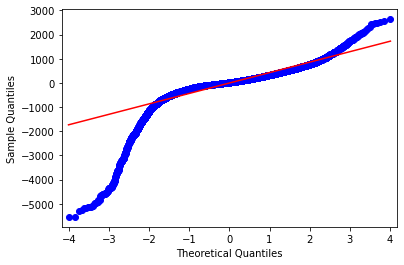

In [53]:
fig = plt.figure(figsize=(6,6))
fig = sm.qqplot(model_to_diag.resid, stats.distributions.norm, line='r') 

**Shapiro-Wilk Test with interaction considered:**

In [54]:
# Shapiro-Wilk Normality Test
from scipy.stats import shapiro
resid_data = list(model_to_diag.resid.values)
stat, p = shapiro(resid_data)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Probably Gaussian')
else:
    print('Probably not Gaussian')

stat=0.754, p=0.000
Probably not Gaussian


### Non-constant Variance

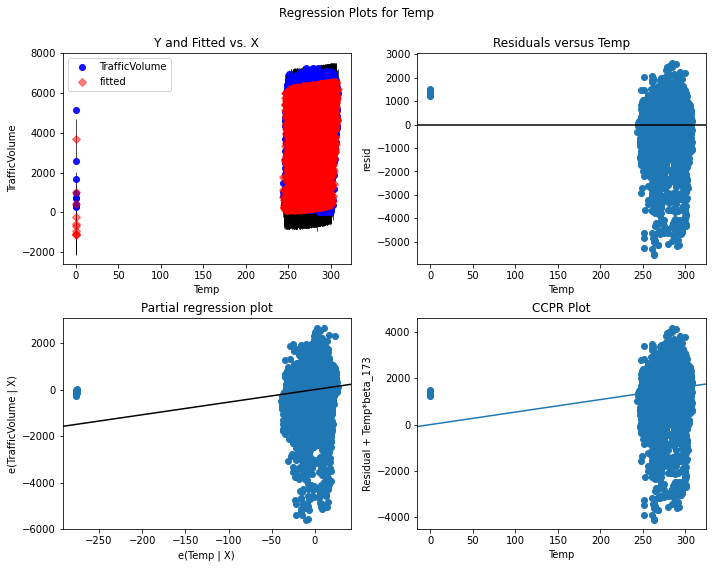

In [55]:
# fitted results versus a single predictor
fig = plt.figure(figsize=(10,8))
fig = sm.graphics.plot_regress_exog(model_to_diag, "Temp", fig=fig)

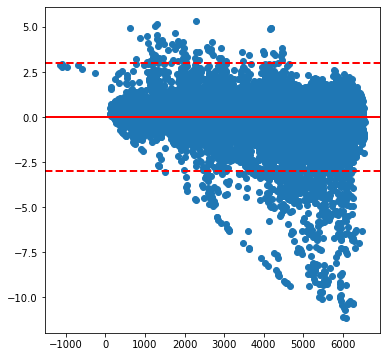

In [56]:
# check the residuals against fitted values
fig = plt.figure(figsize=(6,6))
plt.scatter(model_to_diag.fittedvalues, model_to_diag.resid_pearson)
plt.axhline(y=0, linewidth=2, color = 'r')
plt.axhline(y=3, linestyle='dashed', linewidth=2, color = 'r')
plt.axhline(y=-3, linestyle='dashed', linewidth=2, color = 'r')

In [57]:
from scipy.stats import levene
resid_array=model_to_diag.resid.sort_values()
resid_data=list(resid_array.values)
nslice=int(len(resid_array)/2)
levene(resid_data[:nslice],resid_data[nslice+1:])


LeveneResult(statistic=255.26638654773512, pvalue=2.9933454508810514e-57)

### Independence

(Text(0.5, 0, 'Index'), Text(0, 0.5, 'Residual'))

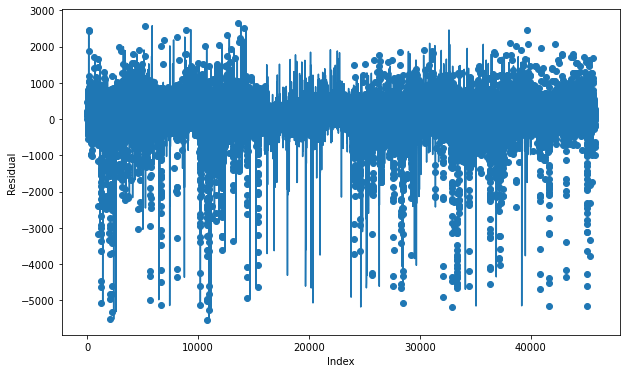

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(dataset['AggHours']-1, model_to_diag.resid)
plt.plot(model_to_diag.resid)
plt.xlabel('Index'), plt.ylabel('Residual')

In [59]:
from statsmodels.stats.stattools import durbin_watson
#perform Durbin-Watson test
durbin_watson(model_to_diag.resid)

0.39869793354754995

In [60]:
resid_df=pd.DataFrame({"Time":dataset["Time"],"residual":model_to_diag.resid}).set_index("Time")

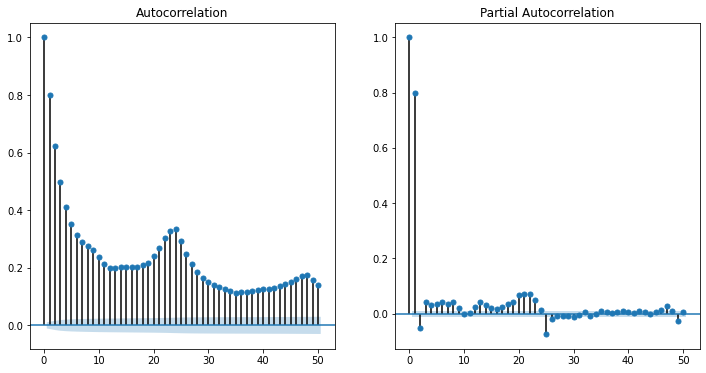

In [61]:
# graphical exploration
alpha=0.05
lags=50
data_t = resid_df
fig, ax = plt.subplots(1,2,figsize=(12,6))
fig = sgt.plot_acf(data_t, ax=ax[0], lags=lags, alpha=alpha, unbiased=True)
fig = sgt.plot_pacf(data_t, ax=ax[1], lags=lags, alpha=alpha, method='ols')

### Box-Cox Transformation

In [62]:
# boxcox变换
dataset_t=dataset.copy()
dataset_t["TrafficVolume"]=dataset_t["TrafficVolume"]+1
ynew, lamb = stats.boxcox(dataset_t["TrafficVolume"])
dataset_t["TrafficVolume"]= ynew

In [63]:
lamb

0.7003342036989291

In [64]:
# include the dummy variable
predictor_cands=["C(d_IsHoliday)","C(WeatherMain_clps)","C(HourDay)","Temp","Rain1h","Snow1h","AggHours","CloudsAll"]
y="TrafficVolume"
fullmodel_t = modelFitting(y, predictor_cands, dataset_t)
# print(fullmodel_t.summary())

fwmodel_t = forward(y, predictor_cands, dataset_t, 'AIC')
fwmodel_t.summary()

['C(HourDay)']
['C(HourDay)', 'Temp']
['C(HourDay)', 'Temp', 'CloudsAll']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)', 'C(d_IsHoliday)']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)', 'C(d_IsHoliday)', 'AggHours']
['C(HourDay)', 'Temp', 'CloudsAll', 'C(WeatherMain_clps)', 'C(d_IsHoliday)', 'AggHours', 'Snow1h']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          TrafficVolume   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     3287.
Date:                Sun, 19 Nov 2023   Prob (F-statistic):               0.00
Time:                        22:58:18   Log-Likelihood:            -1.7626e+05
No. Observations:               33820   AIC:                         3.529e+05
Df Residuals:                   33643   BIC:                         3.544e+05
Df Model:                         176                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -8.7632      6.121     -1.432      0.152     -20.761       3.235
C(HourDay)[T.1]              0.5015      4.429      0.113      0.910      -8.179       9.182
C(HourDay)[T.2]              3.7542      4.419      0.850      0.396      -4.906      12.415
C(HourDay)[T.3]              7.6312      4.414      1.729      0.084      -1.020      16.283
C(HourDay)[T.4]             23.2985      4.388      5.309      0.000      14.697      31.900
C(HourDay)[T.5]             85.5451      4.440     19.265      0.000      76.842      94.248
C(HourDay)[T.6]            101.5635      4.467     22.735      0.000      92.807     110.320
C(HourDay)[T.10]           -33.5559      4.473     -7.502      0.000     -42.323     -24.789
C(HourDay)[T.11]           -34.4672      4.473     -7.706      0.000     -43.234     -25.700
C(HourDay)[T.12]           -30.9264      4.479     -6.905      0.000     -39.705     -22.148
C(HourDay)[T.13]           -30.4701      4.435     -6.870      0.000     -39.164     -21.777
C(HourDay)[T.14]           -20.5710      4.430     -4.643      0.000     -29.254     -11.888
C(HourDay)[T.15]            26.0580      4.420      5.895      0.000      17.394      34.722
C(HourDay)[T.16]            37.5822      4.451      8.443      0.000      28.858      46.307
C(HourDay)[T.20]           -49.1888      4.440    -11.077      0.000     -57.892     -40.485
C(HourDay)[T.21]           -50.6867      4.473    -11.331      0.000     -59.454     -41.919
C(HourDay)[T.22]           -46.0545      4.441    -10.371      0.000     -54.758     -37.351
C(HourDay)[T.23]           -46.9284      4.451    -10.542      0.000     -55.653     -38.203
C(HourDay)[T.24]           -39.0521      4.441     -8.794      0.000     -47.756     -30.348
C(HourDay)[T.25]             1.3188      4.452      0.296      0.767      -7.407      10.044
C(HourDay)[T.26]             7.5987      4.484      1.695      0.090      -1.191      16.388
C(HourDay)[T.30]           -40.3859      4.473     -9.029      0.000     -49.153     -31.619
C(HourDay)[T.31]           -37.6977      4.484     -8.407      0.000     -46.487     -28.909
C(HourDay)[T.32]           -34.3335      4.513     -7.607      0.000     -43.179     -25.488
C(HourDay)[T.33]           -35.4820      4.479     -7.923      0.000     -44.260     -26.704
C(HourDay)[T.34]           -30.8603      4.426     -6.973      0.000     -39.534     -22.186
C(HourDay)[T.35]           -28.1253      4.485     -6.271      0.000     -36.916     -19.335
C(HourDay)[T.36]           -31.1302      4.513     -6.898      0.000     -39.976     -22.284
C(HourDay)[T.40]            29.0927      4.462      6.520      0.000      20.347      37.839
C(HourDay)[T.41]            34.6475      4.457      7.774      0.000      25.912      43.383
C(HourDay)[T.4

In [65]:
model_to_diag=fwmodel_t
from scipy.stats import shapiro
resid_data = list(model_to_diag.resid.values)
stat, p = shapiro(resid_data)
print('stat=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Normal Distribution: Probably Gaussian')
else:
    print('Normal Distribution: Probably not Gaussian')
    
from scipy.stats import levene
resid_array=model_to_diag.resid.sort_values()
resid_data=list(resid_array.values)
nslice=int(len(resid_array)/2)
print("Constant Variance: "+str(levene(resid_data[:nslice],resid_data[nslice+1:])))

from statsmodels.stats.stattools import durbin_watson
#perform Durbin-Watson test
print("Independence: "+str(durbin_watson(model_to_diag.resid)))

stat=0.732, p=0.000
Normal Distribution: Probably not Gaussian
Constant Variance: LeveneResult(statistic=337.1311377734822, pvalue=6.227591503536203e-75)
Independence: 0.38659698913084406


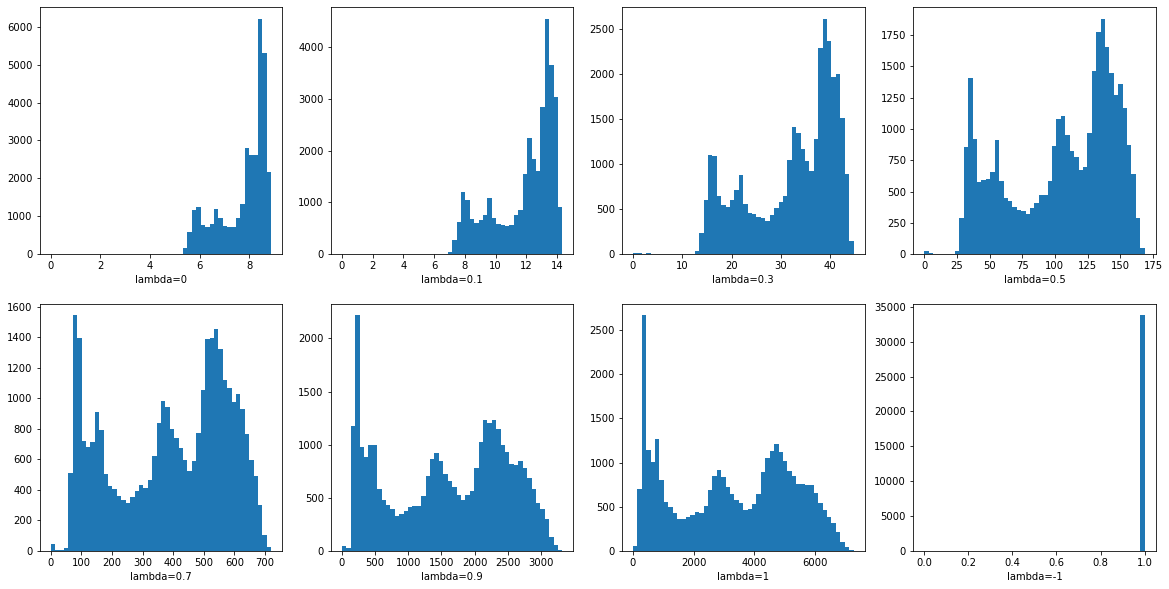

In [66]:
from scipy.special import boxcox 
plt.figure(figsize=(20,10))
locs=[241,242,243,244,245,246,247,248]
lambdas=[0,0.1,0.3,0.5,0.7,0.9,1,-1]
newy=[]
for i in range(len(lambdas)):
    plt.subplot(locs[i])
    dataset_t=dataset.copy()
    dataset_t["TrafficVolume"]=dataset_t["TrafficVolume"]+1
    dataset_t["TrafficVolume"]= boxcox(dataset_t["TrafficVolume"],lambdas[i])
    newy.append(list(dataset_t["TrafficVolume"]))
    plt.hist(dataset_t["TrafficVolume"],bins=50)
    plt.xlabel("lambda="+str(lambdas[i]))

# Ultimate Forecast Model: Regression+ARIMA
## ARIMA on residuals of the originally selected model
**i.e. fwmodel**

In [64]:
resid_df=pd.DataFrame({"Time":dataset["Time"],"residual":fwmodel.resid}).set_index("Time")
data = resid_df

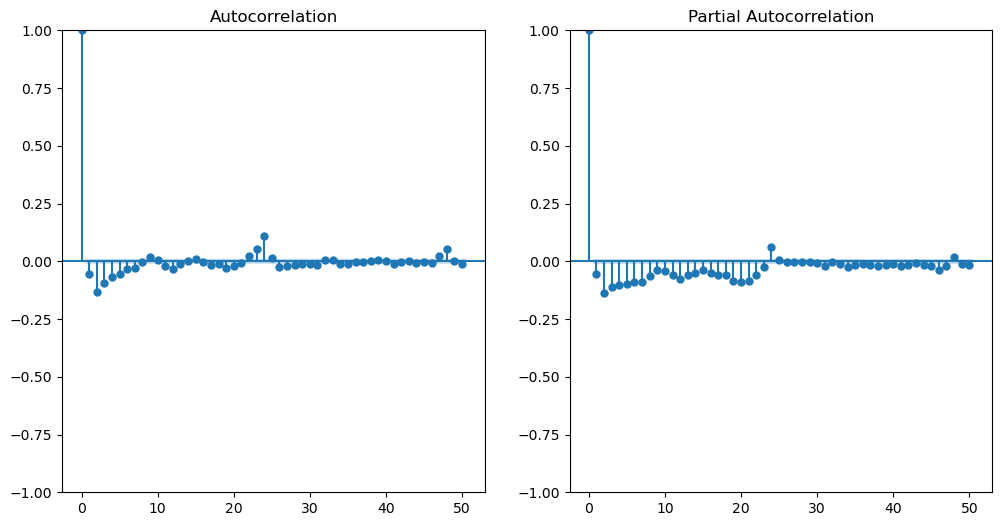

In [65]:
# take the first regular difference
data_d = data.diff(1)
data_d.dropna(inplace=True)
alpha=0.05
lags=50
fig, ax = plt.subplots(1,2,figsize=(12,6))
fig = sgt.plot_acf(data_d, ax=ax[0], lags=lags, alpha=alpha, unbiased=True)
fig = sgt.plot_pacf(data_d, ax=ax[1], lags=lags, alpha=alpha, method='ols')

                               SARIMAX Results                                
Dep. Variable:               residual   No. Observations:                33820
Model:                 ARIMA(2, 0, 0)   Log Likelihood             -240534.236
Date:                Wed, 22 Nov 2023   AIC                         481076.473
Time:                        17:42:37   BIC                         481110.188
Sample:                             0   HQIC                        481087.229
                              - 33820                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.355e-08      8.082  -1.68e-09      1.000     -15.840      15.840
ar.L1          0.8419      0.002    385.564      0.000       0.838       0.846
ar.L2         -0.0513      0.003    -16.514      0.0

Text(0.5, 1.0, 'RSS: 2980413677.0933')

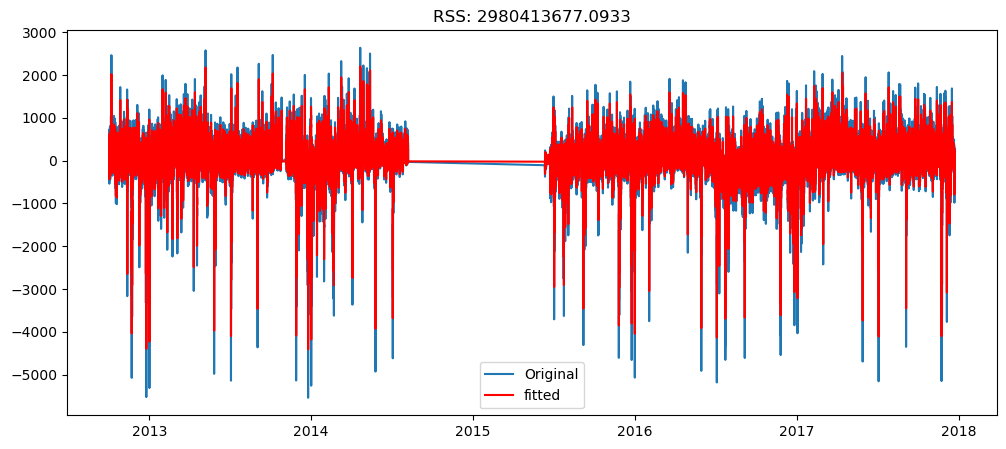

In [68]:
from statsmodels.tsa.arima.model import ARIMA
# initial fit of the model without seasonal component
model = ARIMA(data, order=(2,0,0))  
results_ns = model.fit() 
print(results_ns.summary())

fig = plt.figure(figsize=(12,5))
plt.plot(data, label='Original')
plt.plot(results_ns.fittedvalues, color='red', label='fitted')
plt.legend(loc='best')
plt.title('RSS: %.4f'% sum((results_ns.fittedvalues-data["residual"])**2))

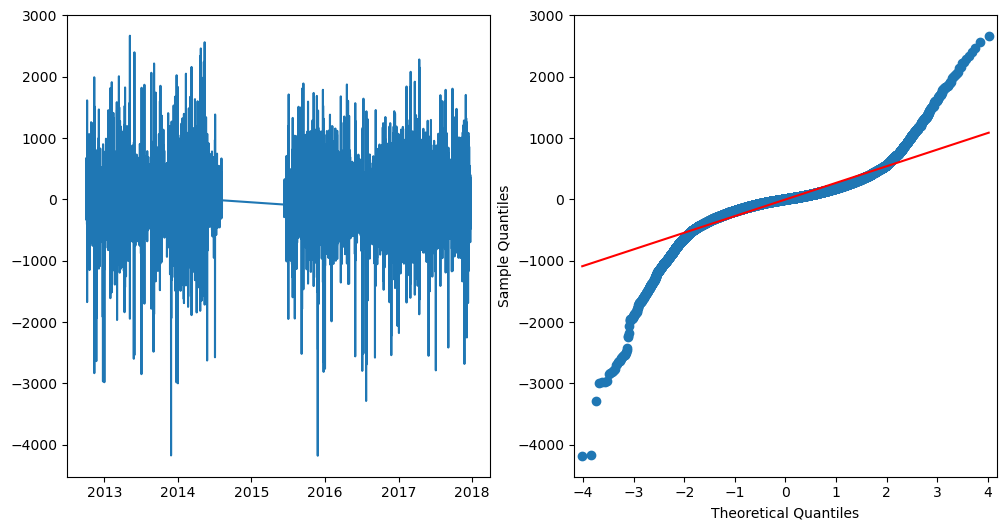

In [69]:
import scipy.stats as stats
res = results_ns.resid
# res = res[25:,]

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].plot(res)
fig = sm.qqplot(res, stats.distributions.norm, line='r', ax=ax[1]) 

## Prediction on two parts
**Make prediction on two parts, including the regression and the ARIMA:**

In [70]:
def transform_exog_to_model(fit, exog):
    transform=True
    self=fit

    # The following is lifted straight from statsmodels.base.model.Results.predict()
    if transform and hasattr(self.model, 'formula') and exog is not None:
        from patsy import dmatrix
        exog = dmatrix(self.model.data.orig_exog.design_info,
                       exog)

    if exog is not None:
        exog = np.asarray(exog)
        if exog.ndim == 1 and (self.model.exog.ndim == 1 or
                               self.model.exog.shape[1] == 1):
            exog = exog[:, None]
        exog = np.atleast_2d(exog)  # needed in count model shape[1]

    # end lifted code
    return exog

In [71]:
# Generate test dataframe
testfile="P2test.csv"
testdata=pd.read_csv(testfile)
testdata["Time"]=pd.to_datetime(testdata["Time"])
testdata["d_IsHoliday"]=testdata["IsHoliday"].map(lambda x:0 if x=="None" else 1)
testdata["AggHours"]=testdata["Time"].map(lambda x:x-dataset["Time"][0])
testdata["AggHours"]=testdata["AggHours"].map(lambda x:24*x.days+(x.seconds)/3600)
testdata["Year"]=testdata["Time"].map(lambda x:x.year)
testdata["Month"]=testdata["Time"].map(lambda x:x.month)
testdata["Date"]=testdata["Time"].map(lambda x:x.date())
testdata["Hour"]=testdata["Time"].map(lambda x:x.hour)
testdata["DayOfWeek"]=testdata["Time"].map(lambda x:x.weekday())
testdata["WeatherMain_clps"]=testdata["WeatherMain"].map( lambda x:1 if x in w1 else 2 if x in w2 else 3 if x in w3 else 4 if x in w4 else 5)
testdata["HourDay"]=testdata["Hour"]*10+testdata["DayOfWeek"]


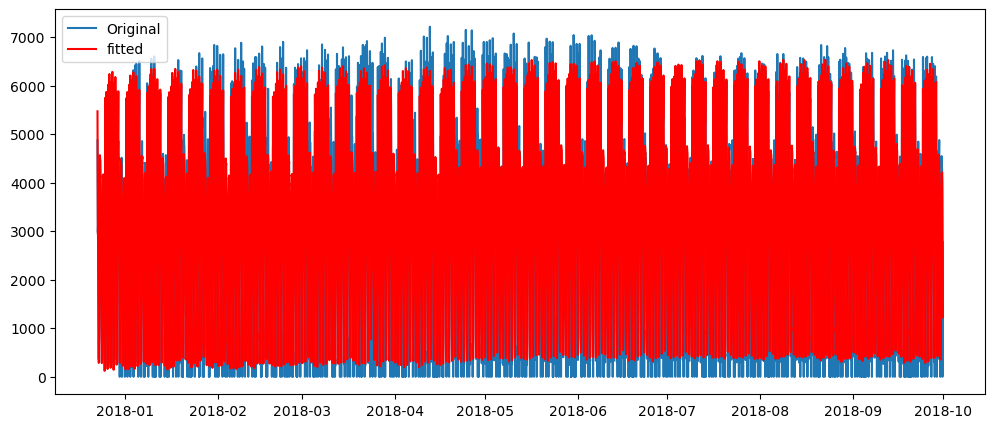

In [72]:
# x_pred = dataset[dataset["AggHours"].isin(range(45775-335,45776))]
x_pred=testdata
# x_pred=testdata

index="Time"
test_tsf=pd.DataFrame({index:list(testdata[index]),"TrafficVolume":list(testdata["TrafficVolume"])})
test_tsf.set_index(index,inplace=True,drop=True)

newdf = x_pred
model_selected=fwmodel # you can change the selected model
y_pred = model_selected.predict(newdf)
pred_df=pd.DataFrame({index:x_pred[index],"TrafficVolume":y_pred}).set_index(index)
fig = plt.figure(figsize=(12,5))
plt.plot(test_tsf, label='Original')
# plt.plot(test_tsf, label='Original')
plt.plot(pred_df, color='red', label='fitted')
plt.legend(loc='best')

In [73]:
# y_pred[y_pred["TrafficVolume"]==y_pred[1]]
y_pred

0       5471.569567
1       4609.941172
2       3549.221352
3       2951.207802
4       2907.966246
           ...     
8199    3151.703843
8200    2736.500528
8201    2324.967325
8202    1812.929607
8203    1225.585493
Length: 8204, dtype: float64

In [74]:
from sklearn.metrics import mean_squared_error
mean_squared_error(pred_df,test_tsf)
# mean_squared_error(pred_df,test_tsf)

892701.8373530852

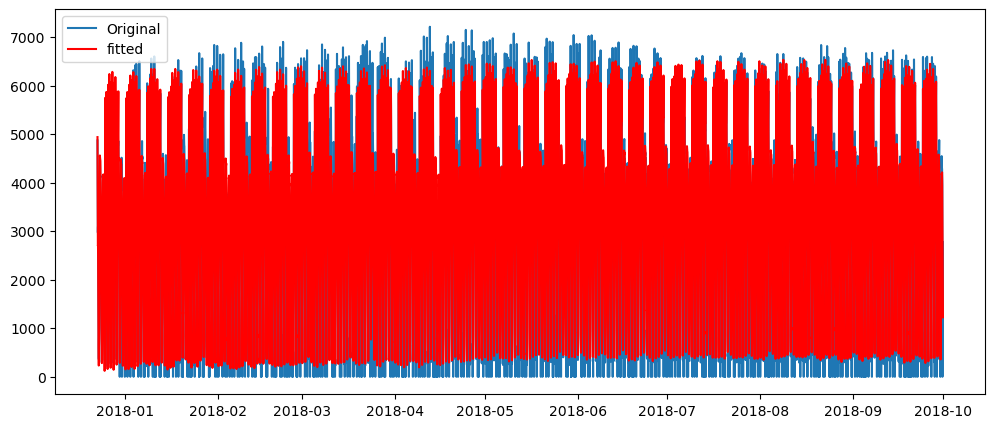

In [80]:
#forecast residuals
pred_resid=results_ns.forecast(8204)
pred_resid_df=pd.DataFrame({"Time":list(testdata.iloc[0:8204][index]),"residual":list(pred_resid)}).set_index("Time")
# add the residuals to the regression forecast results to generate the ultimate dataframe
pred_resid_df["TrafficVolume"]=pred_resid_df["residual"]
pred_resid_df=pred_resid_df.drop(columns="residual")
ultimate_pred=pred_resid_df+pred_df

fig = plt.figure(figsize=(12,5))
plt.plot(test_tsf, label='Original')
plt.plot(ultimate_pred, color='red', label='fitted')
plt.legend(loc='best')

In [81]:
from sklearn.metrics import mean_squared_error
mean_squared_error(ultimate_pred,test_tsf)

892650.9980426083

In [84]:
missing_pred=pd.DataFrame({"Time":[],"TrafficVolume":[]}).set_index("Time")
for i in range(len(test_tsf)):
    if test_tsf.iloc[i]["TrafficVolume"]==0:
        missing_pred=pd.concat([missing_pred,ultimate_pred.iloc[i]],axis=0)

In [85]:
missing_pred.to_csv("Regression_ARIMA_Forecast.csv")

# Regression+ES
## ES on residuals

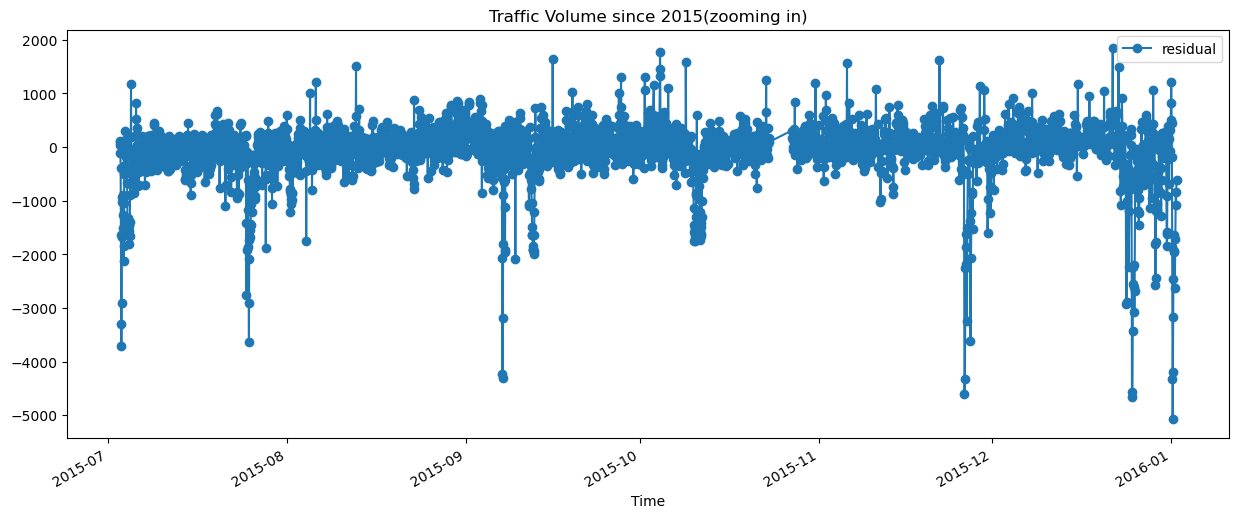

In [86]:
ax = data["2015-7-3":"2016-1-1"].plot(figsize=(15,6), marker='o', title="Traffic Volume since 2015(zooming in)" )
# ax = data["2017-7-4":"2017-11-23"].plot(figsize=(10,6), marker='o', title="Traffic Volume from 2017-7-4 to 2017-11-23" )

<Axes: title={'center': "Forecasts from Holt-Winters' method"}, xlabel='Time', ylabel='Traffic Volume'>

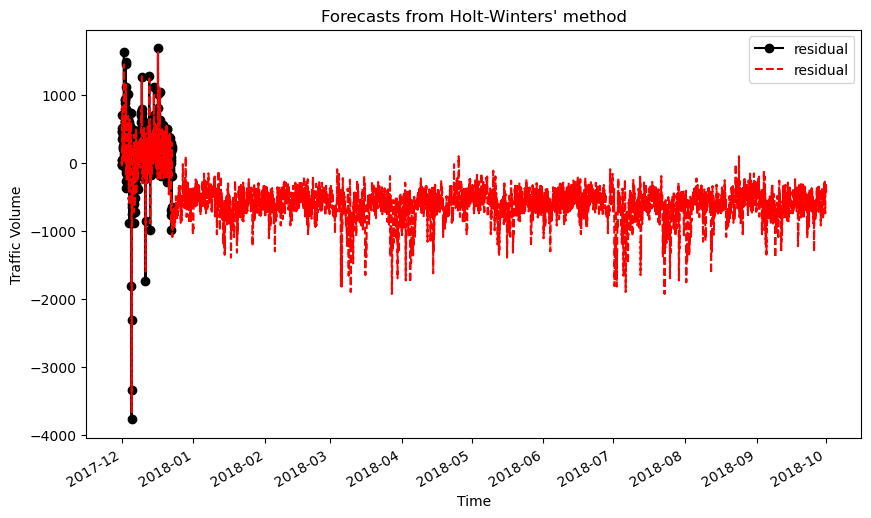

In [87]:
from statsmodels.tsa.api import ExponentialSmoothing as ES, SimpleExpSmoothing, Holt
tsf_to_go=data
fit1 = ES(tsf_to_go, seasonal_periods=24*142,trend=None, seasonal="add",).fit()

ax = tsf_to_go["2017-12":].plot(figsize=(10,6), marker='o', color='black', title="Forecasts from Holt-Winters' method" )
ax.set_ylabel("Traffic Volume")
ax.set_xlabel("AggHours")
fit1.fittedvalues["2017-12":].plot(ax=ax, style='--', color='red')
es_pred=fit1.forecast(8204).values
es_pred_df=pd.DataFrame({"Time":list(testdata.iloc[0:8204][index]),"residual":list(es_pred)}).set_index("Time")
es_pred_df.plot(ax=ax, style='--', color='red',legend=True)

In [88]:
pred_df

,TrafficVolume
Time,
2017-12-22 17:00:00,5471.569567
2017-12-22 18:00:00,4609.941172
2017-12-22 19:00:00,3549.221352
2017-12-22 20:00:00,2951.207802
2017-12-22 21:00:00,2907.966246
...,...
2018-09-30 19:00:00,3151.703843
2018-09-30 20:00:00,2736.500528
2018-09-30 21:00:00,2324.967325


## Prediction on ES+Regression

In [89]:
# only run once:
es_pred_df["TrafficVolume"]=es_pred_df["residual"]
es_pred_df=es_pred_df.drop(columns="residual")

In [90]:
reg_es_pred=es_pred_df+pred_df
for i in range(len(pred_df)):
    if reg_es_pred.iloc[i]["TrafficVolume"]<0:
        reg_es_pred.iloc[i]["TrafficVolume"]=pred_df.iloc[i]["TrafficVolume"]

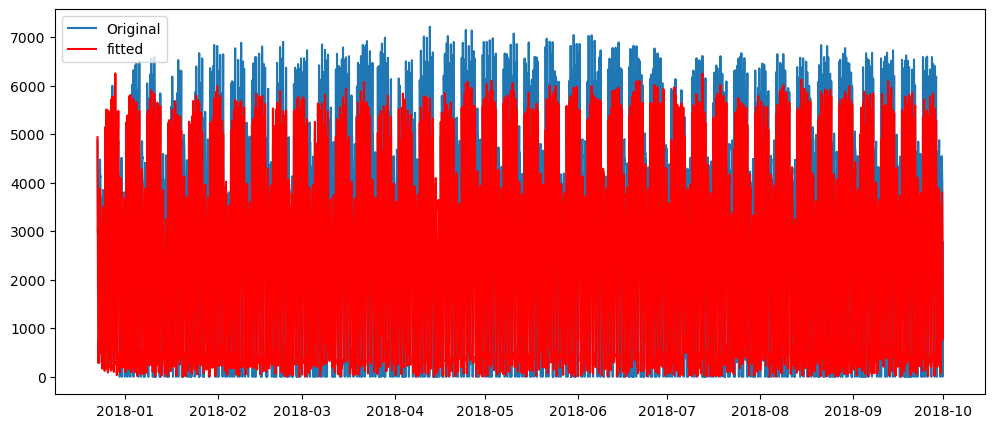

In [91]:
fig = plt.figure(figsize=(12,5))
plt.plot(test_tsf, label='Original')
plt.plot(reg_es_pred, color='red', label='fitted')
plt.legend(loc='best')

In [92]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
from math import sqrt
print("MSE=",mean_squared_error(reg_es_pred,test_tsf))
print("MAE=",mean_absolute_error(reg_es_pred,test_tsf))
print("RMSE=",sqrt(mean_squared_error(reg_es_pred,test_tsf)))


MSE= 1000861.7960912846
MAE= 698.4861091857931
RMSE= 1000.430805249061


In [94]:
missing_pred=pd.DataFrame({"Time":[],"TrafficVolume":[]}).set_index("Time")
for i in range(len(test_tsf)):
    if test_tsf.iloc[i]["TrafficVolume"]==0:
        missing_pred=pd.concat([missing_pred,reg_es_pred.iloc[i]],axis=0)

In [95]:
missing_pred.to_csv("Regression_ES_Forecast.csv")

# Generate TimeSeries data

In [96]:
index="Time"
tsf=pd.DataFrame({index:list(dataset[index]),"TrafficVolume":list(dataset["TrafficVolume"])})
tsf.set_index("Time",inplace=True,drop=True)
date_range=pd.date_range(start="2012-10-02 9:00",end="2017-12-22 16:00",freq="1H")
complete_tsf=pd.DataFrame()
complete_tsf["Time"]=date_range
complete_tsf["TrafficVolume"]=complete_tsf["Time"].map(lambda x:tsf["TrafficVolume"][x] if x in tsf.index else np.nan)
complete_tsf.set_index("Time",inplace=True,drop=True)
complete_tsf["TrafficVolume"].ffill(inplace=True)

**Transform the response variable:**

In [97]:
log_tsf=np.log(complete_tsf)
inf_index=log_tsf[log_tsf["TrafficVolume"]==-np.inf].index
for i in inf_index:
    log_tsf["TrafficVolume"][i]=0

# Exponential smoothing
**resampling data:**

In [98]:
# tsf to be used in particular period
tsf_to_go=log_tsf["2015-6":]

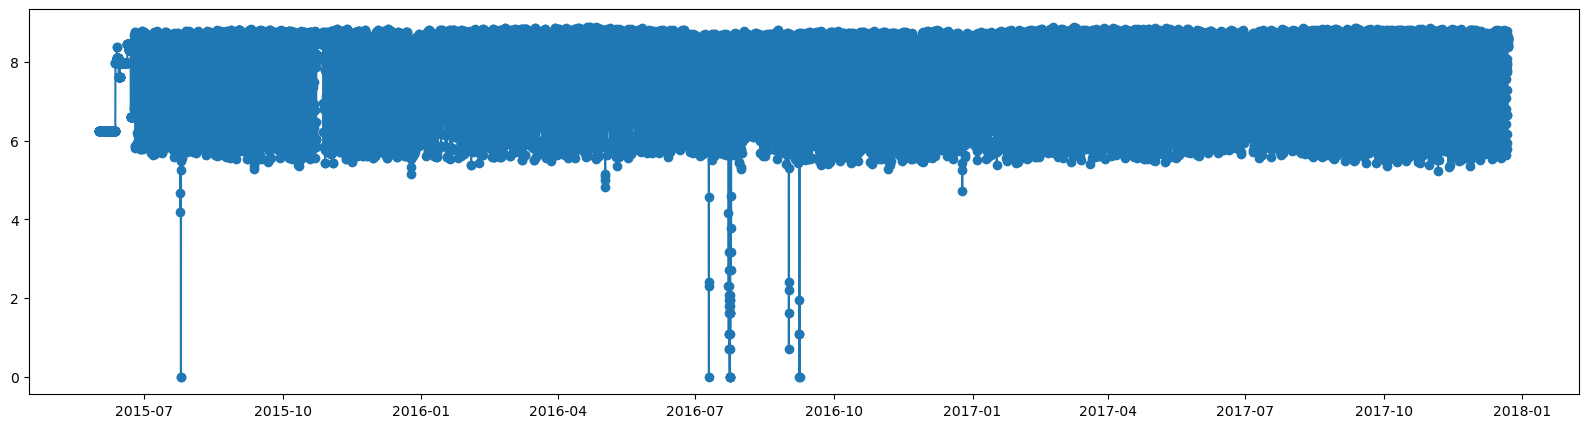

In [99]:
fig, ax=plt.subplots(figsize=(20,5))
plt.plot(tsf_to_go.index, tsf_to_go, marker="o")

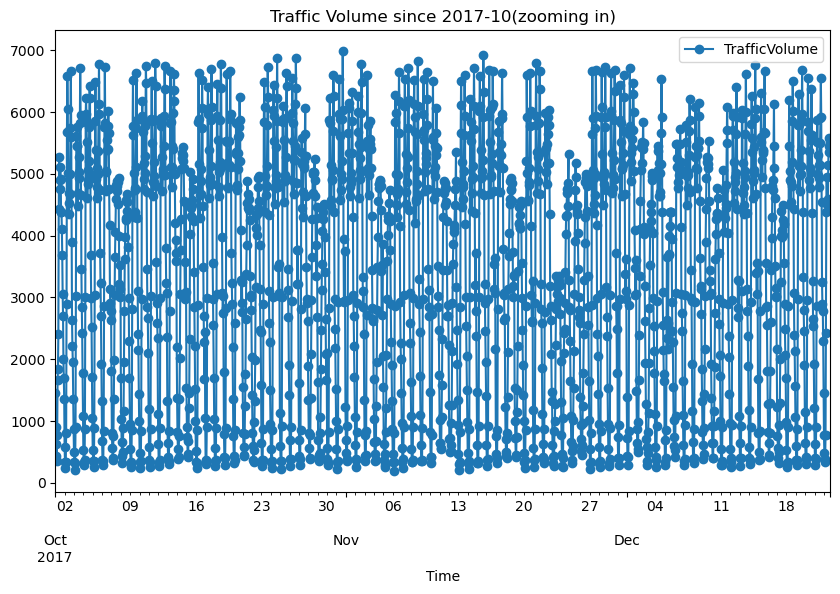

In [100]:
ax = complete_tsf["2017-10":].plot(figsize=(10,6), marker='o', title="Traffic Volume since 2017-10(zooming in)" )

## model fitting

### using ewm

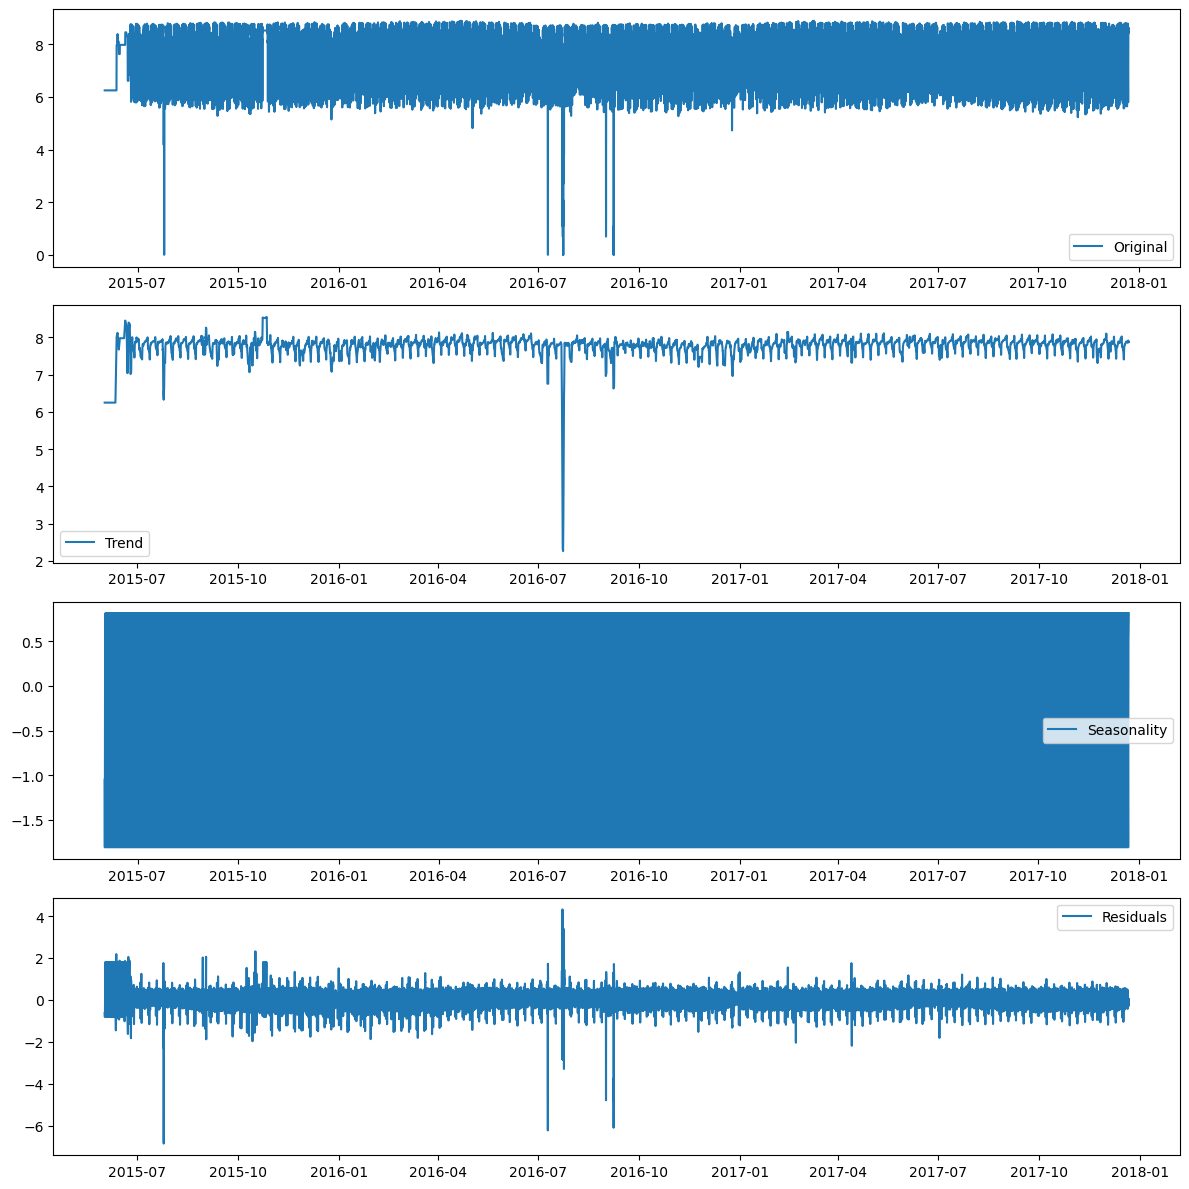

In [101]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(tsf_to_go)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

fig, ax = plt.subplots(4,1,figsize=(12,12))
plt.subplot(411)
plt.plot(tsf_to_go, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()

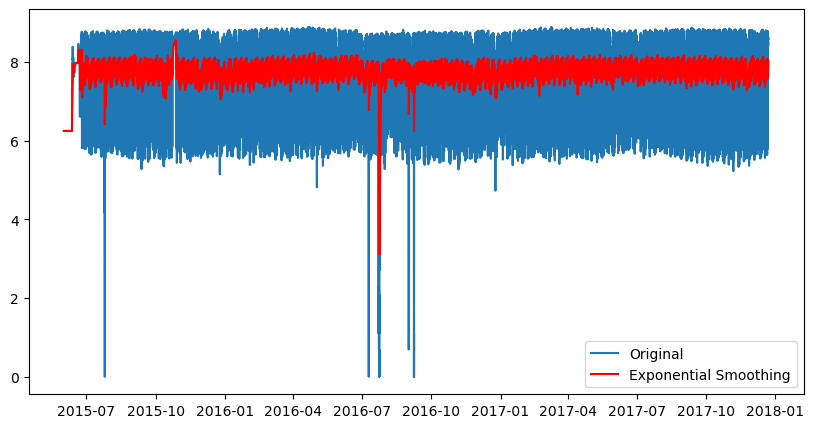

In [102]:
ewm = tsf_to_go.ewm(alpha=0.05, min_periods=0)

fig = plt.figure(figsize=(10,5))
plt.plot(tsf_to_go, label='Original')
plt.plot(ewm.mean(), color='red', label='Exponential Smoothing')
plt.legend(loc='best')

### using packages& making forecast

In [103]:
import time

<Axes: title={'center': "Forecasts from Holt-Winters' method"}, xlabel='Time', ylabel='Traffic Volume'>

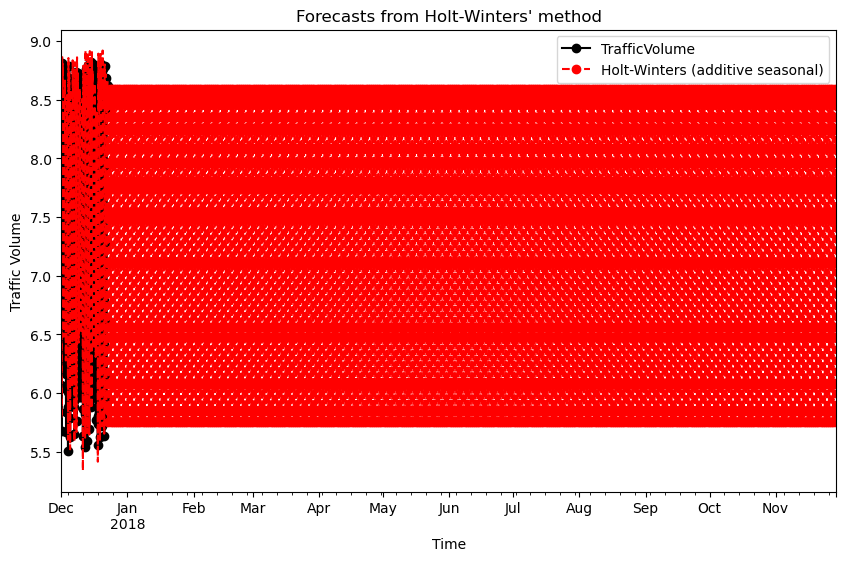

In [104]:
from statsmodels.tsa.api import ExponentialSmoothing as ES, SimpleExpSmoothing, Holt
fit1 = ES(tsf_to_go, seasonal_periods=24, trend=None, seasonal='add').fit()

ax = tsf_to_go["2017-12":].plot(figsize=(10,6), marker='o', color='black', title="Forecasts from Holt-Winters' method" )
ax.set_ylabel("Traffic Volume")
ax.set_xlabel("AggHours")
fit1.fittedvalues["2017-12":].plot(ax=ax, style='--', color='red')
fit1.forecast(8204).rename('Holt-Winters (additive seasonal)').plot(ax=ax, style='--', marker='o', color='red', legend=True)

In [106]:
start_time=time.time()
fit1 = ES(tsf_to_go, seasonal_periods=24, trend=None, seasonal='add').fit()
fit1.forecast(8204)
end_time=time.time()
elapsed_time = end_time - start_time 
print(elapsed_time)
print(fit1.summary())

0.23776912689208984
                       ExponentialSmoothing Model Results                       
Dep. Variable:            TrafficVolume   No. Observations:                22457
Model:             ExponentialSmoothing   SSE                           1862.026
Optimized:                         True   AIC                         -55864.524
Trend:                             None   BIC                         -55656.021
Seasonal:                      Additive   AICC                        -55864.452
Seasonal Periods:                    24   Date:                 Wed, 22 Nov 2023
Box-Cox:                          False   Time:                         17:53:16
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.9313475                alpha                 True
smoot

7046145.815282717


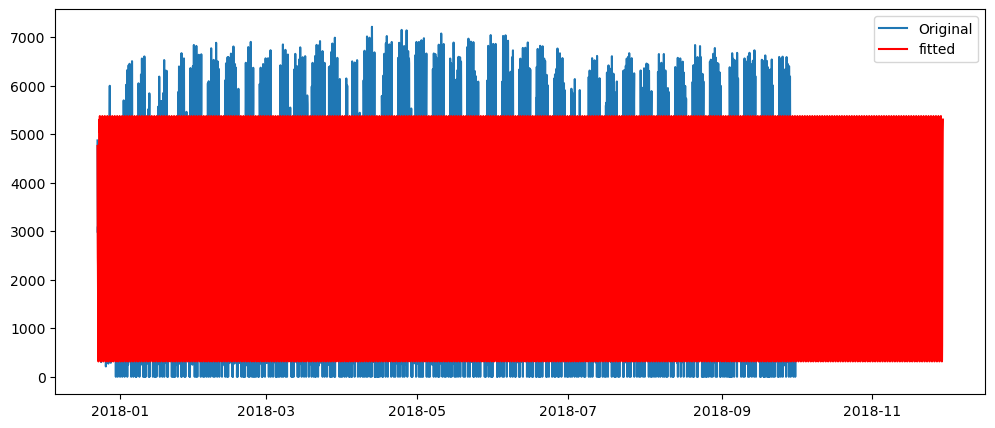

In [107]:
fig = plt.figure(figsize=(12,5))
plt.plot(test_tsf[0:8204], label='Original')
plt.plot(np.exp(fit1.forecast(8204)), color='red', label='fitted')
plt.legend(loc='best')
print(mean_squared_error(np.exp(fit1.forecast(8204)),test_tsf[0:8204]))

## consecutive one-step prediction on test-data

In [96]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

tsf_to_go=complete_tsf["2015-6":]

def exp_smoothing_forecast(history, config):
    t,d,s,p,b,r = config
    # define model
    history = np.array(history)
    model = ExponentialSmoothing(history, trend=t, damped=d, seasonal=s, seasonal_periods=p)
    # fit model
    model_fit = model.fit(optimized=True, use_boxcox=b, remove_bias=r)
    # make one step forecast
    yhat = model_fit.predict(len(history), len(history))
    return yhat[0]

cfg=["add",False,"add",24,False,False]
history=list(tsf_to_go["TrafficVolume"])
pred_lst=[]
test_lst=list(test_tsf[0:335]["TrafficVolume"])
start_time1=time.time()
for i in test_lst:
    yhat=exp_smoothing_forecast(history,cfg)
    pred_lst.append(yhat)
    history.append(i)
end_time1=time.time()
elapsed_time1 = end_time1 - start_time1
print(elapsed_time1)

883.0260353088379


1261805.4122256385


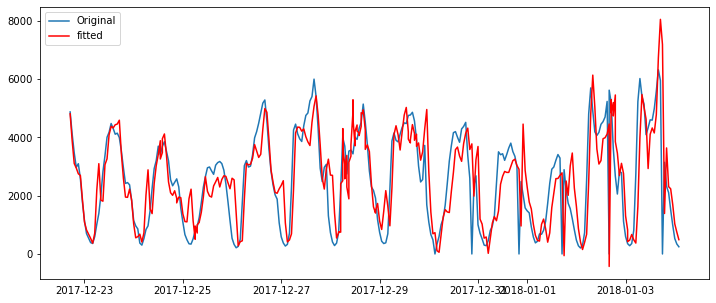

In [97]:
esm_pred_df=pd.DataFrame({"Time":list(test_tsf[0:335].index),"TrafficVolume":pred_lst,}).set_index("Time")
fig = plt.figure(figsize=(12,5))
plt.plot(test_tsf[0:335], label='Original')
plt.plot(esm_pred_df, color='red', label='fitted')
plt.legend(loc='best')

print(mean_squared_error(esm_pred_df,test_tsf[0:335]))

# SARIMA

In [108]:
tsf_to_go=log_tsf["2015-6":]

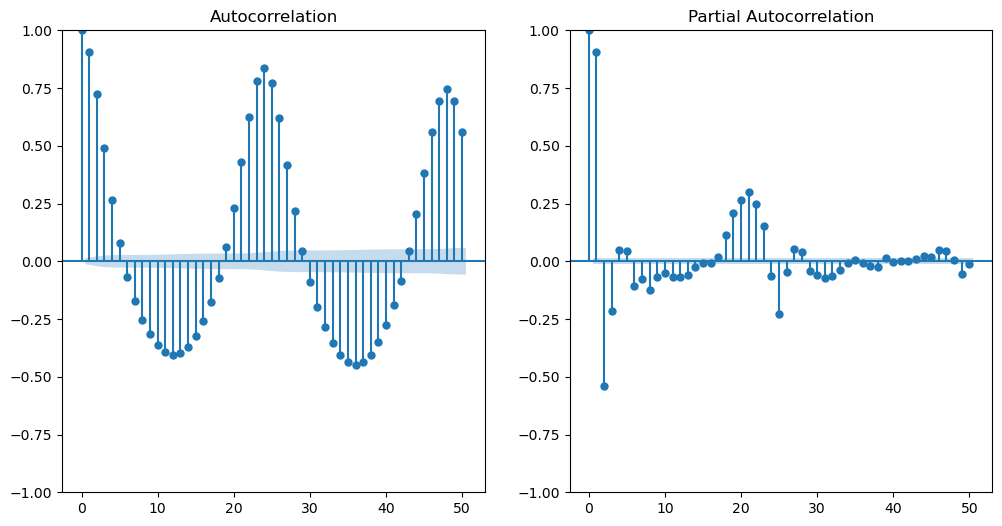

In [109]:
# graphical exploration
alpha=0.05
lags=50
data = tsf_to_go
fig, ax = plt.subplots(1,2,figsize=(12,6))
fig = sgt.plot_acf(data, ax=ax[0], lags=lags, alpha=alpha, unbiased=True)
fig = sgt.plot_pacf(data, ax=ax[1], lags=lags, alpha=alpha, method='ols')

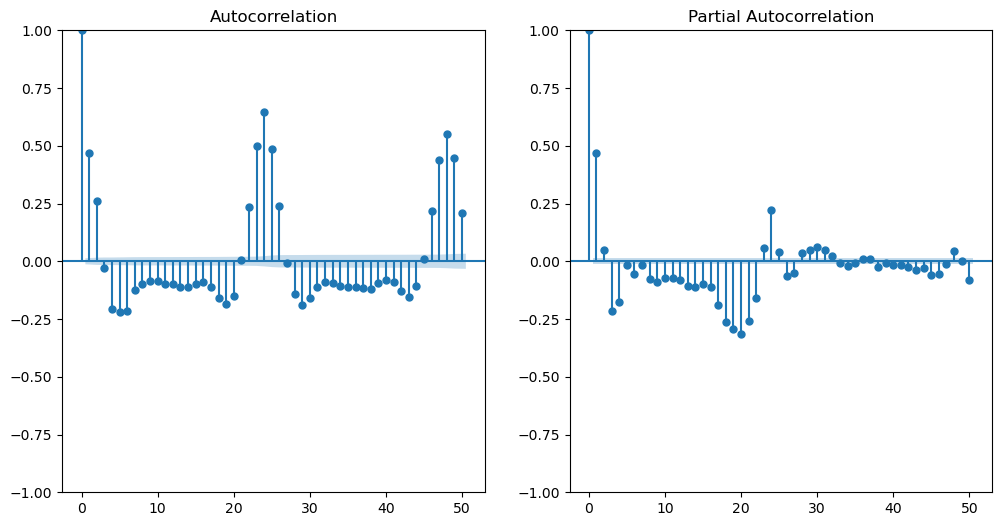

In [110]:
# take the first regular difference
data = tsf_to_go.diff(1)
data.dropna(inplace=True)
fig, ax = plt.subplots(1,2,figsize=(12,6))
fig = sgt.plot_acf(data, ax=ax[0], lags=lags, alpha=alpha, unbiased=True)
fig = sgt.plot_pacf(data, ax=ax[1], lags=lags, alpha=alpha, method='ols')

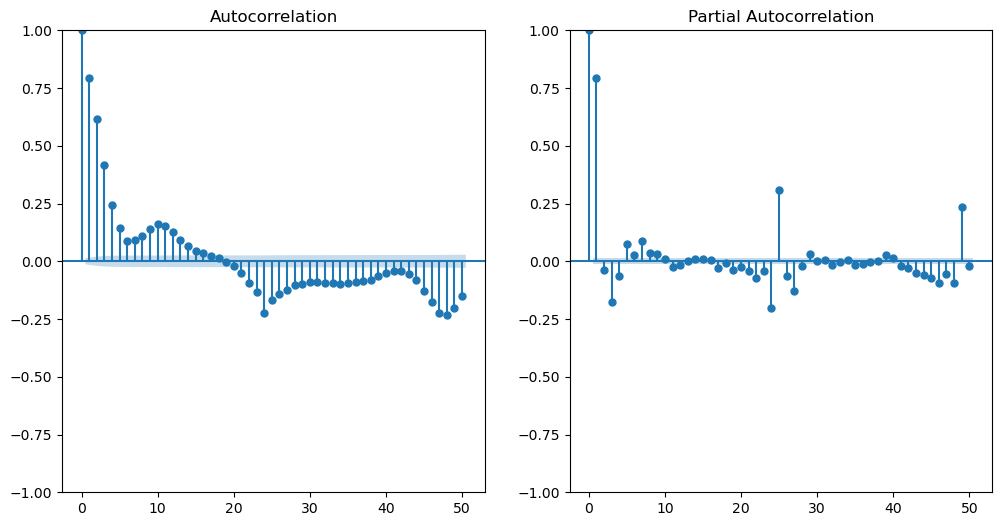

In [111]:
# take the first seasonal difference
data = tsf_to_go.diff(24)
data.dropna(inplace=True)
fig, ax = plt.subplots(1,2,figsize=(12,6))
fig = sgt.plot_acf(data, ax=ax[0], lags=lags, alpha=alpha, unbiased=True)
fig = sgt.plot_pacf(data, ax=ax[1], lags=lags, alpha=alpha, method='ols')

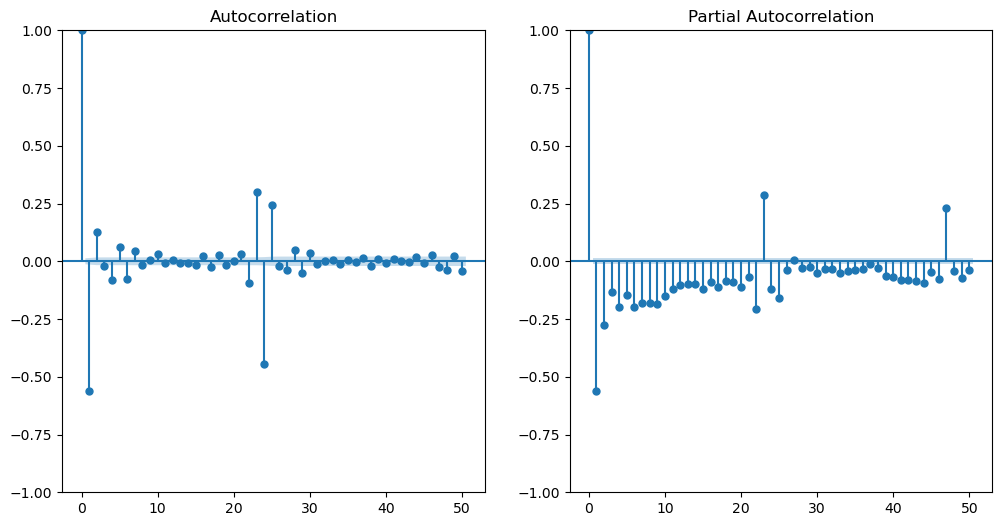

In [112]:
# take the first regular and seasonal difference
data = tsf_to_go.diff(1).diff(1).diff(24)
data.dropna(inplace=True)
fig, ax = plt.subplots(1,2,figsize=(12,6))
fig = sgt.plot_acf(data, ax=ax[0], lags=lags, alpha=alpha, unbiased=True)
fig = sgt.plot_pacf(data, ax=ax[1], lags=lags, alpha=alpha, method='ols')

**I'm sorry that the SARIMA model below can't be re-run due to insufficient computer memory, but it can still be run on my computer before 2023-11-19.**

In [113]:
import statsmodels.api as sm
model = sm.tsa.SARIMAX(tsf_to_go, trend='n', order=(0,2,2), seasonal_order=(0,1,1,24))#,simple_differencing=True)
result_sm = model.fit()
print(result_sm.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        TrafficVolume   No. Observations:                22457
Model:             SARIMAX(0, 2, 2)x(0, 1, [1], 24)   Log Likelihood               -3342.940
Date:                              Wed, 22 Nov 2023   AIC                           6693.879
Time:                                      17:58:01   BIC                           6725.952
Sample:                                  06-01-2015   HQIC                          6704.314
                                       - 12-22-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9823      0.002   -469.495      0.000      -0.986      -0.978
ma.L2         -0.01

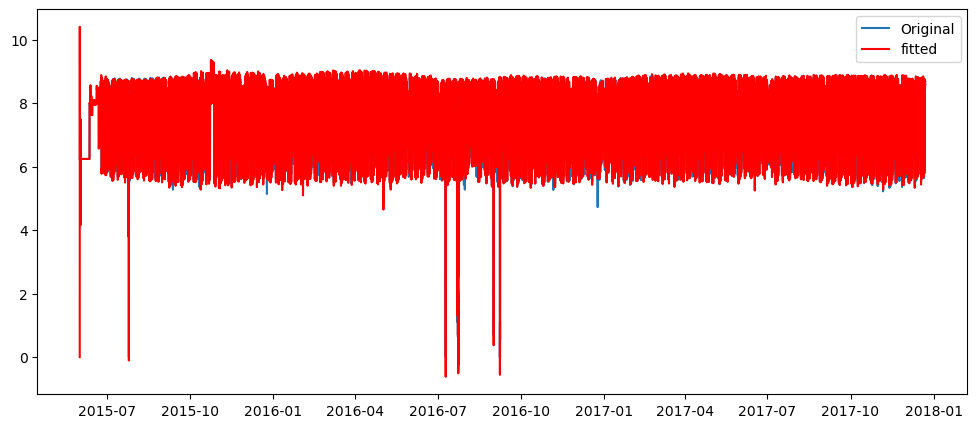

In [114]:
fitval = result_sm.fittedvalues

fig = plt.figure(figsize=(12,5))
plt.plot(tsf_to_go, label='Original')
plt.plot(fitval, color='red', label='fitted')
plt.legend(loc='best')

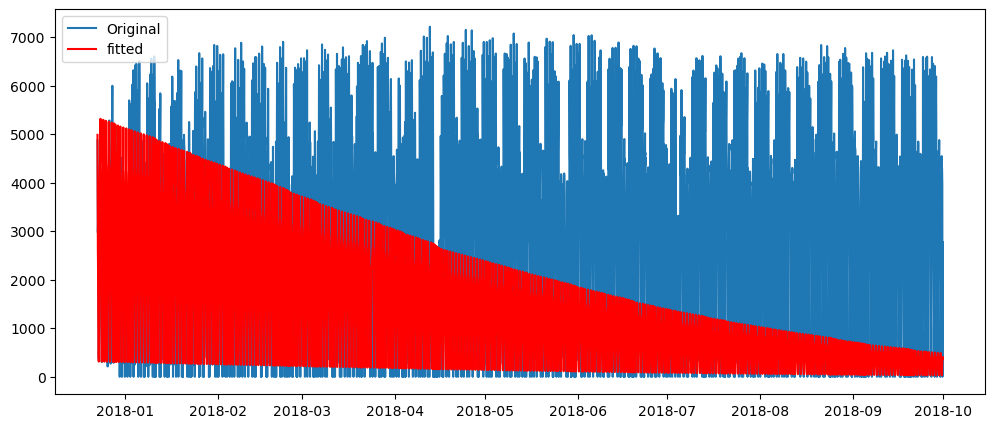

In [116]:
sarima_pred=np.exp(result_sm.forecast(8204))
sarima_pred_df=pd.DataFrame({"Time":list(testdata.iloc[0:8204][index]),"TrafficVolume":list(sarima_pred)}).set_index("Time")
fig = plt.figure(figsize=(12,5))
plt.plot(test_tsf[0:8204], label='Original')
plt.plot(sarima_pred_df, color='red', label='fitted')
plt.legend(loc='best')

In [117]:
from sklearn.metrics import mean_squared_error
mean_squared_error(sarima_pred_df,test_tsf[0:8204])

8674137.183943983

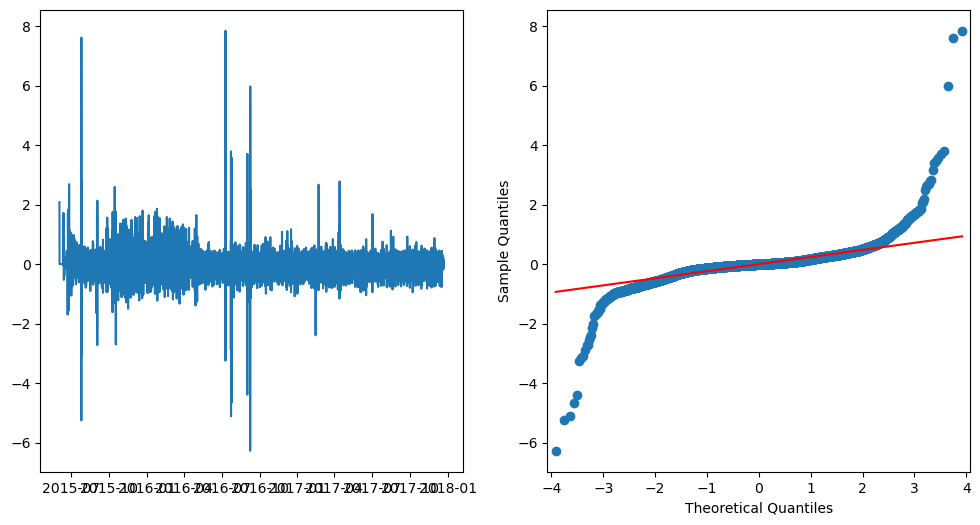

In [118]:
import scipy.stats as stats
res = result_sm.resid
res = res[25:,]

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].plot(res)
fig = sm.qqplot(res, stats.distributions.norm, line='r', ax=ax[1]) 

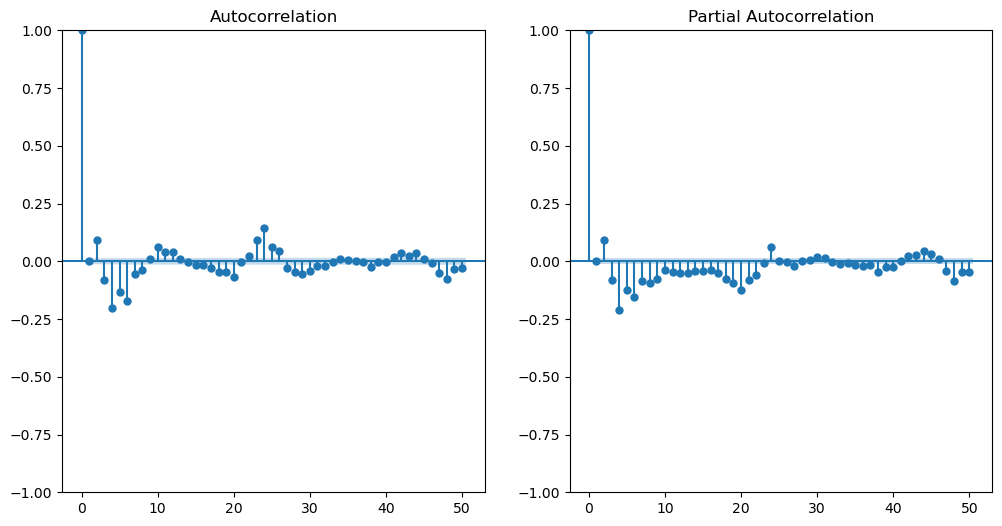

In [119]:
fig, ax = plt.subplots(1,2,figsize=(12,6))
fig = sgt.plot_acf(res, ax=ax[0], lags=lags, alpha=alpha, unbiased=True)
fig = sgt.plot_pacf(res, ax=ax[1], lags=lags, alpha=alpha, method='ols')

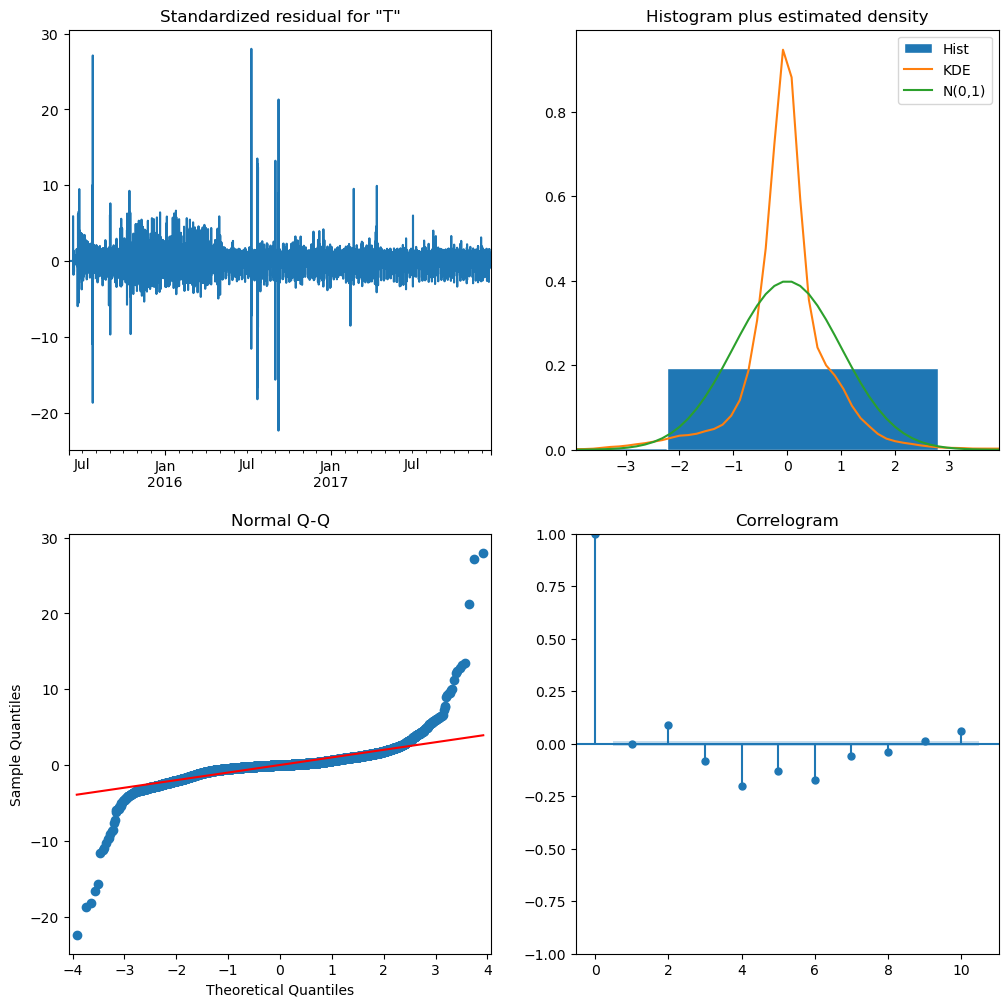

In [120]:
fig = result_sm.plot_diagnostics(figsize=(12,12))
plt.show()